In [55]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_circuit_layout
import math
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library.standard_gates import MCXGate
from qiskit_aer.noise import thermal_relaxation_error, depolarizing_error, NoiseModel, ReadoutError # collection of realistic noise types (gate errors, decoherence, readout errors) modeled to simulate behavior of real quantum devices.
from qiskit.providers.fake_provider import GenericBackendV2

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


\begin{equation}
H \cdot X \cdot H = Z
\end{equation}

---
- Hadamard gate ($H$):

\begin{equation*}
H = \frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
\end{equation*}

- Pauli-X gate ($X$):

\begin{equation*}
X =
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
\end{equation*}

- Pauli-Z gate ($Z$):

\begin{equation*}
Z =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
\end{equation*}

---

Applying the transformations:

1. The Hadamard gate ($H$) maps the computational basis ($|0 \rangle , |1\rangle$) to the superposition basis ($|+\rangle, |-\rangle$).  
2. The $X$ gate swaps $|0\rangle \leftrightarrow |1\rangle$.  
3. Conjugating $X$ by $H$ rotates the operation into the Z-basis.



\begin{equation}
(H \cdot X) \cdot H = \frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
-1 & 1
\end{pmatrix} \frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix} = \frac{1}{2}
\begin{pmatrix}
2 & 0 \\
0 & -2
\end{pmatrix} =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix} = Z

\end{equation}



In [56]:
# The built-in 'MCXGate' flips the target qubit if ALL controls are in state "1".

# We'll treat the *last qubit* as the "target" for the multi-controlled X, 
#   1. Put H on last qubit
#   2. MCX on that last qubit
#   3. Put H back on last qubit
# That effectively gives MCZ      [ H.MCX.H = MCZ ]

# The Hadamard-X-Hadamard (H·X·H)=Z trick is used here to simulate a multi-controlled Z (MCZ) gate.  
# We use a multi-controlled X (MCX) gate, which is natively supported by most quantum hardware, 
# and sandwich it between Hadamard (H) gates.  
# The H gates effectively transform the target qubit into the X basis, allowing the MCX gate  
# to act like a phase-flip (Z gate) instead of a bit-flip (X gate).  
# This approach is both hardware-friendly and scalable for multi-controlled operations,  

def grover_oracle(n, m=1):
    """
    Build an oracle that marks:
        - '111...1' (for m=1)
        - '111...1' AND '111...10' (for m=2) 
    by applying a phase flip (multiply by -1) on those states.
    """
    qc = QuantumCircuit(n, name="Oracle")
    # Mark |111...1>:
    qc.h(n-1)  # applies a Hadamard  to the last qubit 
    mcx_gate = MCXGate(n-1)  # creates a multi-controlled X with n-1 controls (MCX aka Toffoli). MCZ gates are harder to implement.
    controls = list(range(n-1))  # first n-1 qubits as controls , e.g   n=4: controls = list(range(3)) --> [0, 1, 2]
    target = n-1                # last qubit is target
    qc.append(mcx_gate, controls + [target]) # qc.append(gate, qubits that the gate acts upon), In Qiskit, the target qubit is always the last qubit in the list passed to append()
    qc.h(n-1) # applies a Hadamard  to the last qubit 

    if m == 2:
        # --------
        # Mark the state |111...10>
        # --------
        # That means the last qubit is 0, the others are 1. 
        # We'll do something similar, but we only want the last qubit to be 0. 
        # So we can apply an X on the last qubit to turn that "0" -> "1" for the control,
        # then do the same approach.
        qc.x(n-1)           # Because we want that qubit to be "1" as a control for MCX
        qc.h(n-1)
        mcx_gate_2 = MCXGate(n-1)
        qc.append(mcx_gate_2, controls + [target])
        qc.h(n-1)
        qc.x(n-1)
    qc.barrier() # Barriers are added to divide the different parts of the circuits    
    return qc
    
    
"""
------------------------------------------------------------------------------------
    # DETAILED COMMENT ON ANCILLA QUBITS USAGE IN QUANTUM ORACLES

    Using ancilla qubits in constructing the oracle has both advantages and disadvantages, depending on the
    complexity of the problem and the constraints of the quantum hardware.

    ------------------------------------------------------------------------------------
    ADVANTAGES OF USING ANCILLA QUBITS:
    1. Simplifies Complex Oracles:
       - For complex logical operations (e.g., evaluating Boolean expressions, arithmetic comparisons),
         ancilla qubits can store intermediate results.
       - This simplifies the implementation by breaking the process into modular steps using ancillas as temporary workspaces.

    2. Reduces Gate Depth:
       - Ancillas can reduce the depth of quantum circuits by enabling parallel processing of multiple logical operations.
       - Instead of chaining multiple gates sequentially, intermediate results stored in ancillas allow for fewer gate layers.

    3. Improves Reversibility:
       - Quantum operations must be reversible (unitary).
       - Ancilla qubits store intermediate computations, simplifying the reversal process required to restore the original state.

    4. Extends Functionality:
       - Allows constructing more expressive oracles, such as arithmetic comparisons, modular arithmetic, or database-like queries.
       - Enables operations requiring multiple steps, like computing a hash function or parity checks.

    5. Better Scalability for Certain Problems:
       - For larger datasets or complex conditions, ancillas make it easier to scale the oracle design by reusing smaller components in a modular approach.

    ------------------------------------------------------------------------------------
    DISADVANTAGES OF USING ANCILLA QUBITS:
    1. Increased Qubit Requirements:
       - Quantum hardware often has limited qubits, and introducing ancillas increases the total qubit count, which may not be feasible for devices with few available qubits.

    2. Higher Circuit Complexity:
       - Ancilla-based implementations often require more gates for initialization and cleanup, leading to higher gate count and deeper circuits.

    3. More Noise and Errors:
       - Each additional qubit introduces more opportunities for errors due to decoherence and gate errors, especially on noisy intermediate-scale quantum (NISQ) devices.

    4. Cleanup Operations:
       - Ancilla qubits used during computation often need to be reset or uncomputed at the end of the oracle operation to return to a clean state.
       - This cleanup process introduces additional gates and complexity.

    5. Slower Execution Time:
       - More qubits and gates result in longer execution times (increased circuit depth), which is problematic in the presence of noise and limited coherence times.

    6. Optimization Challenges:
       - Designing ancilla-based circuits requires optimization techniques to minimize ancilla usage, reduce depth, and simplify reversibility, adding a layer of design complexity.

    ------------------------------------------------------------------------------------
    WHEN TO USE ANCILLAS:
    - Simple Oracles (No Ancillas):
      - If the oracle involves only bitwise checks or phase flips, such as Grover's search for marked states, no ancillas are needed.
      - Example: Multi-controlled NOT (MCX) for directly marking solutions.

    - Complex Oracles (Ancillas Needed):
      - If the oracle evaluates complex conditions, such as:
        1. Logical expressions (e.g., f(x, y, z) = (x AND y) XOR z)
        2. Arithmetic comparisons (e.g., x < 42)
        3. Hash functions or parity checks
      - Ancillas are necessary to store intermediate results and ensure reversibility.

    ------------------------------------------------------------------------------------
    CONCLUSION:
    - Use no ancillas when the oracle can be expressed using simple phase flips or controlled gates (e.g., Grover's algorithm).
    - Use ancillas for complex oracles involving logical or arithmetic operations, especially when modular design and reversibility are required.
    - For noisy quantum devices, minimizing the number of qubits and gate depth is often prioritized, which is why Grover's algorithm typically avoids ancilla qubits unless absolutely necessary.
    ------------------------------------------------------------------------------------
    """

"\n------------------------------------------------------------------------------------\n    # DETAILED COMMENT ON ANCILLA QUBITS USAGE IN QUANTUM ORACLES\n\n    Using ancilla qubits in constructing the oracle has both advantages and disadvantages, depending on the\n    complexity of the problem and the constraints of the quantum hardware.\n\n    ------------------------------------------------------------------------------------\n    ADVANTAGES OF USING ANCILLA QUBITS:\n    1. Simplifies Complex Oracles:\n       - For complex logical operations (e.g., evaluating Boolean expressions, arithmetic comparisons),\n         ancilla qubits can store intermediate results.\n       - This simplifies the implementation by breaking the process into modular steps using ancillas as temporary workspaces.\n\n    2. Reduces Gate Depth:\n       - Ancillas can reduce the depth of quantum circuits by enabling parallel processing of multiple logical operations.\n       - Instead of chaining multiple gates 

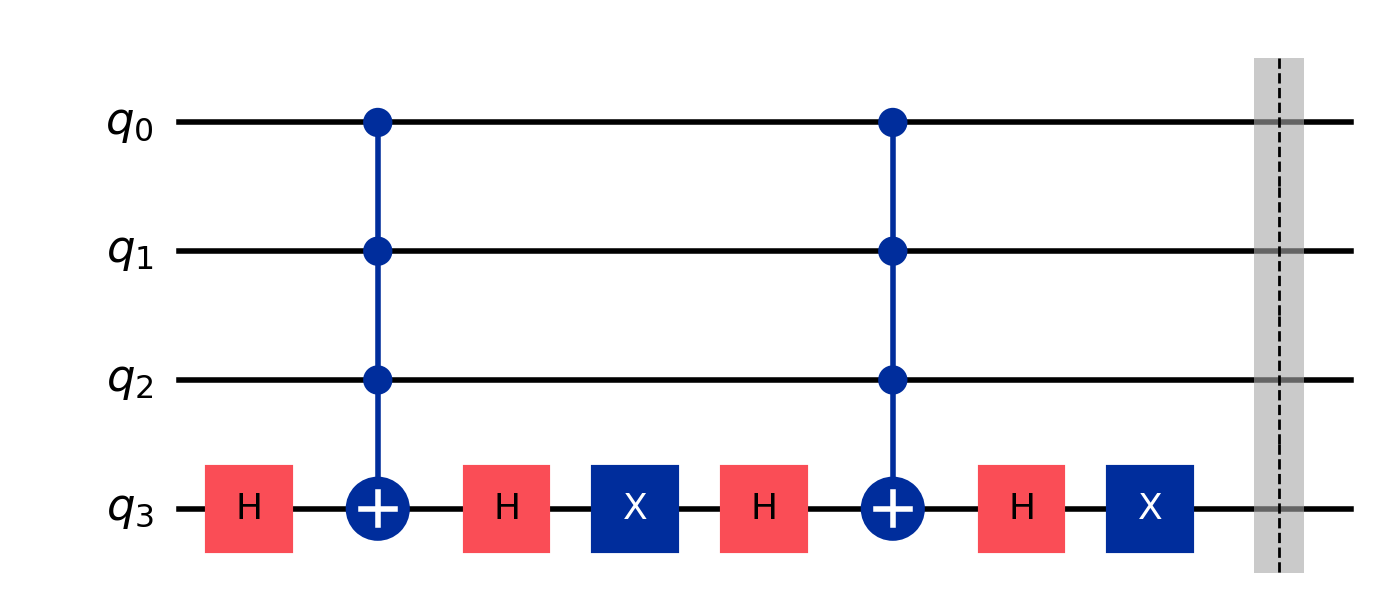

In [57]:
oracle = grover_oracle(n=4, m=2)  
oracle.draw('mpl')

In qiskit the ordering is reversed , $ \ x=5$ :

\begin{aligned}
\text{in usual binary:  } & |q_3', q_2', q_1', q_0'\rangle = | 0,1,0,1 \rangle \text{  big-endian} \\
\text{in Qiskit:  }       & |q_3, q_2, q_1, q_0\rangle=|q_0', q_1', q_2', q_3'\rangle = | 1,0,1,0 \rangle 
\end{aligned}

-->  Qiskit = little-endian :  right most qubit, $q_0$, is the least significant bit 

In [58]:
def test_oracle_on_basis(n, m):
    # Simulator
    simulator = AerSimulator()
    
    for x in range(2**n):
        # Prepare |x>   i.e.  Convert the integer x into its binary representation.
        qc = QuantumCircuit(n) # Creates a new quantum circuit with n qubits in the |00...00> state
        for qubit_i in range(n):
            if ((x >> qubit_i) & 1) == 1:
                qc.x(qubit_i)  # Set each qubit to 1 if needed
                
        # Apply the oracle
        oracle = grover_oracle(n, m)
        qc.compose(oracle, inplace=True) # appends the oracle circuit to the current quantum circuit qc modifying it in-place.

        # Simulate and extract the statevector
        qc.save_statevector() # Saves the final quantum state of the circuit, Statevector simulation allows us to inspect the full quantum state instead of just sampling measurements.
        t_qc = transpile(qc, simulator) #  Optimizes and converts the circuit to a format compatible with the quantum simulator backend i.e. reorganizes operations based on the constraints of the selected hardware or simulator.
        result = simulator.run(t_qc).result() # Executes the transpiled quantum circuit on the simulator to compute the final quantum state. The output contains the statevector (amplitudes for all basis states).
        final_state = result.get_statevector(qc)

        # Check the amplitude for the prepared state
        amplitude = final_state[x]
        phase_change = amplitude / (1+0j)  # Check relative to initial amplitude (1.0)

        print(f"|{x:04b}> -> amplitude = {amplitude:.2f}, phase_change ~ {phase_change:.2f}")
        
# Test with n=4, m=2
test_oracle_on_basis(n=4, m=2) # Important : |0111> in Qiskit’s printed basis actually corresponds to ∣1110⟩ in the “usual” labeling.


|0000> -> amplitude = 1.00+0.00j, phase_change ~ 1.00+0.00j
|0001> -> amplitude = 1.00+0.00j, phase_change ~ 1.00+0.00j
|0010> -> amplitude = 1.00+0.00j, phase_change ~ 1.00+0.00j
|0011> -> amplitude = 1.00+0.00j, phase_change ~ 1.00+0.00j
|0100> -> amplitude = 1.00+0.00j, phase_change ~ 1.00+0.00j
|0101> -> amplitude = 1.00+0.00j, phase_change ~ 1.00+0.00j
|0110> -> amplitude = 1.00+0.00j, phase_change ~ 1.00+0.00j
|0111> -> amplitude = -1.00-0.00j, phase_change ~ -1.00-0.00j
|1000> -> amplitude = 1.00+0.00j, phase_change ~ 1.00+0.00j
|1001> -> amplitude = 1.00+0.00j, phase_change ~ 1.00+0.00j
|1010> -> amplitude = 1.00+0.00j, phase_change ~ 1.00+0.00j
|1011> -> amplitude = 1.00+0.00j, phase_change ~ 1.00+0.00j
|1100> -> amplitude = 1.00+0.00j, phase_change ~ 1.00+0.00j
|1101> -> amplitude = 1.00+0.00j, phase_change ~ 1.00+0.00j
|1110> -> amplitude = 1.00+0.00j, phase_change ~ 1.00+0.00j
|1111> -> amplitude = -1.00-0.00j, phase_change ~ -1.00-0.00j


True solutions: ['1111']
Number of Grover iterations = 3


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


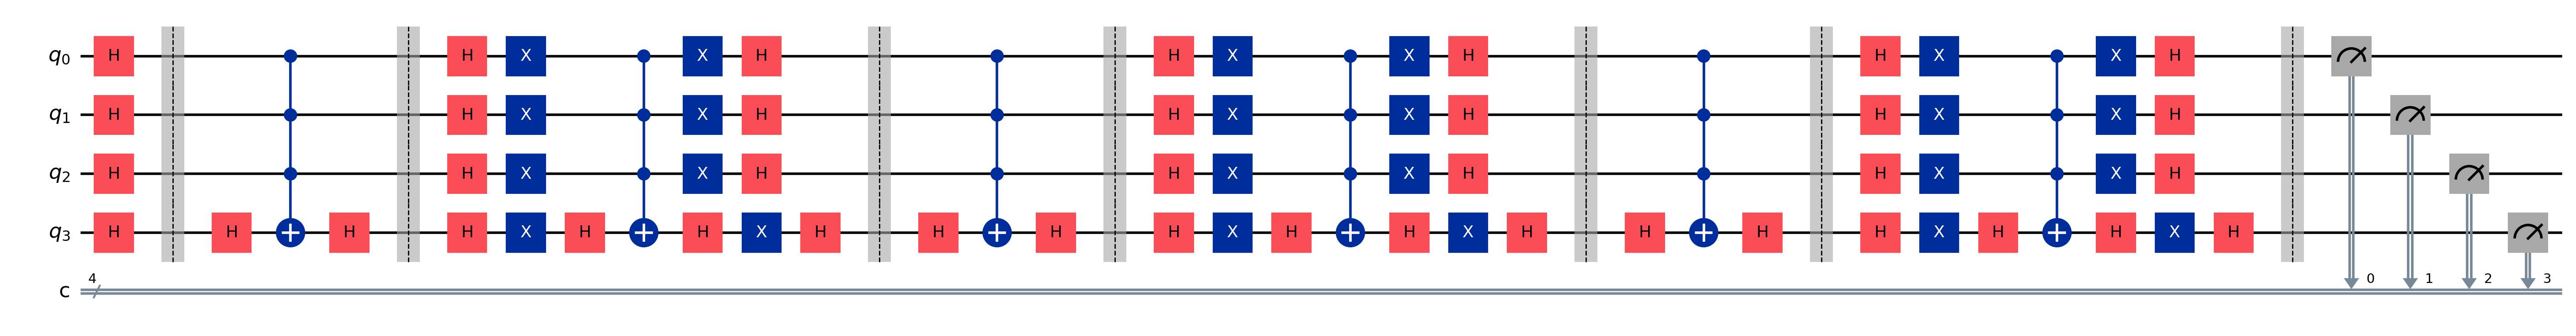

In [59]:
##############################################################################
# 2) Diffuser = 2|psi><psi| - I  (on n qubits)
##############################################################################
def diffuser(n):
    """
    Implements the "inversion about the mean" or "diffuser":
       D = 2|psi><psi| - I
    which can also be done as:
       H^n -> X^n -> H on last qubit -> MCX -> H on last qubit -> X^n -> H^n
    """
    qc = QuantumCircuit(n, name='Diffuser')
    
    # 1) Hadamard on all qubits
    qc.h(range(n))
    # 2) X on all qubits
    qc.x(range(n))
    # 3) Multi-controlled Z (via MCX on last qubit, with H to convert X->Z)
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    # 4) X on all qubits
    qc.x(range(n))
    # 5) Hadamard on all qubits
    qc.h(range(n))

    qc.barrier()
    return qc


##############################################################################
# 3) Define the Grover operator G = (2|psi><psi| - I) * Oracle
##############################################################################
def grover_operator(n, m=1):
    """
    Returns a QuantumCircuit implementing G = (2|psi><psi| - I) * O
    on n qubits, using the provided grover_oracle(n, m) and the diffuser.
    """
    qc = QuantumCircuit(n, name='GroverOperator')
    
    # -- First apply the Oracle O
    oracle_circ = grover_oracle(n, m)
    qc.compose(oracle_circ, range(n), inplace=True)

    # -- Then apply the diffuser (2|psi><psi| - I)
    diff_circ = diffuser(n)
    qc.compose(diff_circ, range(n), inplace=True)

    return qc


##############################################################################
# 4) Full Grover search algorithm
##############################################################################
def grover_search(n, m=1, shots=1024):
    """
    Builds and runs a full Grover's algorithm circuit:
      1) Start in |0...0>
      2) Apply H^n to get |psi> (equal superposition)
      3) Apply G = (2|psi><psi|-I)*O, R times
      4) Measure
    Returns the final circuit and the measurement counts.
    
    n = number of qubits
    m = number of "marked" solutions (1 or 2, given the oracle above)
    """
    # Create a QuantumCircuit with n qubits + n classical bits
    qc = QuantumCircuit(n, n)
    
    # Step 1 & 2: Start in |0..0>, then apply H^n
    for qubit in range(n):
        qc.h(qubit)
    qc.barrier()    

    # Number of iterations R ~ pi/4 * sqrt(2^n / m)
    R = int(round((math.pi / 4) * math.sqrt((2**n) / m)))
    print(f"Number of Grover iterations = {R}")

    # Step 3: apply G = (2|psi><psi|-I)*O, R times
    G = grover_operator(n, m)
    for _ in range(R):
        qc.compose(G, range(n), inplace=True)

    # Step 4: measure
    qc.measure(range(n), range(n))

    # Execute on the AerSimulator
    simulator = AerSimulator()                 # Instantiate the simulator
    transpiled_qc = transpile(qc, simulator)   # Transpile for that backend
    result = simulator.run(transpiled_qc, shots=shots).result()
    counts = result.get_counts()

    return qc, counts

def generate_true_solutions(n, m):
    """
    Generate 'm' true solutions for an n-qubit system.
    """
    true_solutions = []
    for i in range(m):
        # Generate solutions starting from '111...1' and decrement
        solution = bin((2 ** n) - 1 - i)[2:]  # Convert to binary, padded to n bits
        true_solutions.append(solution.zfill(n))  # Ensure padding for n bits
    return true_solutions

##############################################################################
# 5) Example usage
##############################################################################

# searching for '111...1' (and '111...10' if m=2).
n = 4
m = 1   # solutions to the search problem i.e. number of marked states
shots = 1000

true_solutions = generate_true_solutions(n, m)
print("True solutions:", true_solutions)

final_circuit, measurement_counts = grover_search(n, m, shots)
final_circuit.draw('mpl', fold=-1, filename="full_circuit.eps")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


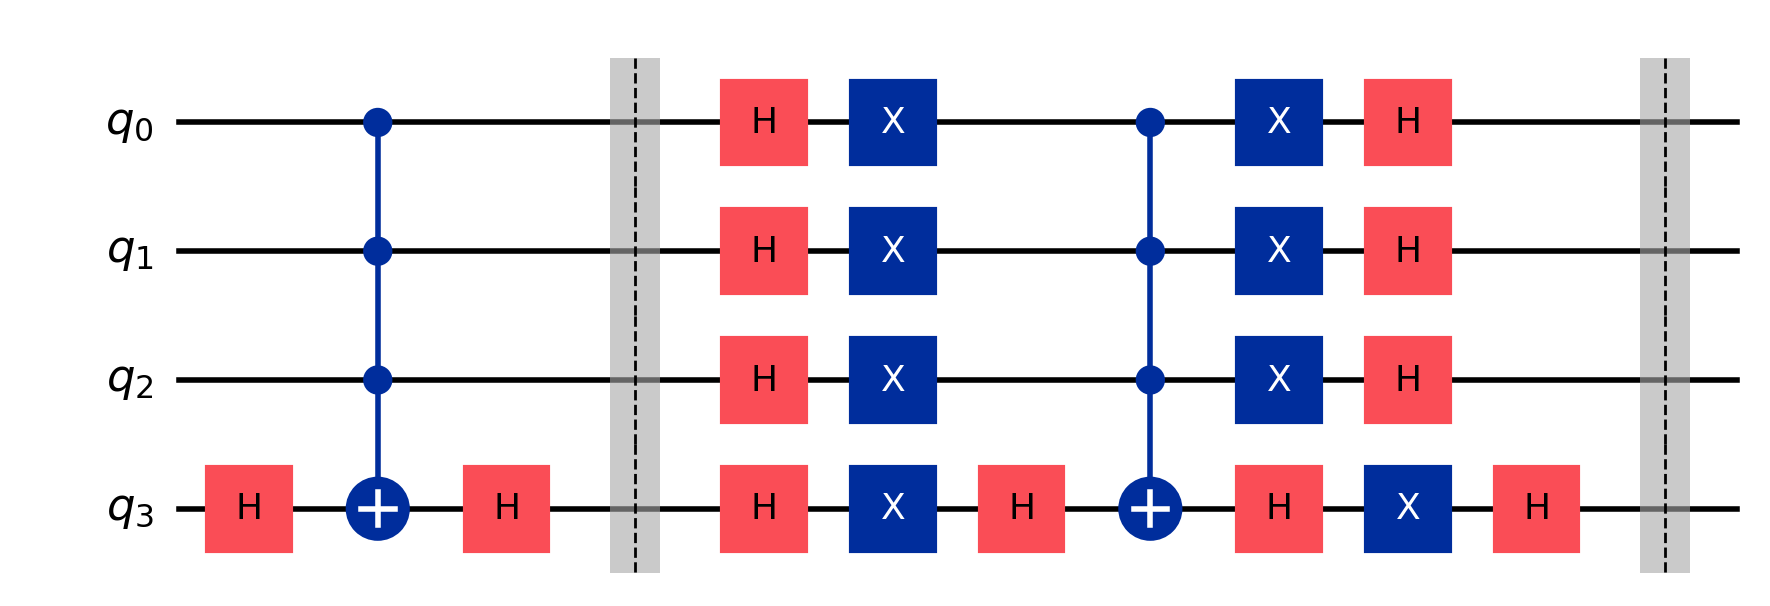

In [60]:
grover_circ = grover_operator(n, m)
grover_circ.draw('mpl', fold=-1, filename="Grover_Operator_circ_n=4_m=1.eps")

In [61]:
# Classical Register (c):
# ----------------------
# The classical register `c` is used to store the measurement results of the quantum circuit.
# At the end of the circuit, each qubit is measured, and the results are written to the corresponding bit
# in the classical register. For example:
# - The quantum state of `q_0` is measured, and the result (0 or 1) is stored in `c[0]`.
# - Similarly, the quantum state of `q_1` is measured, and the result (0 or 1) is stored in `c[1]`.
#
# This process collapses the quantum states into classical values (0 or 1), allowing the results
# of the quantum computation to be analyzed or used in a classical context. The classical register
# ensures the quantum-to-classical transition, which is critical for interpreting quantum computation
# results and making decisions based on the outcomes.


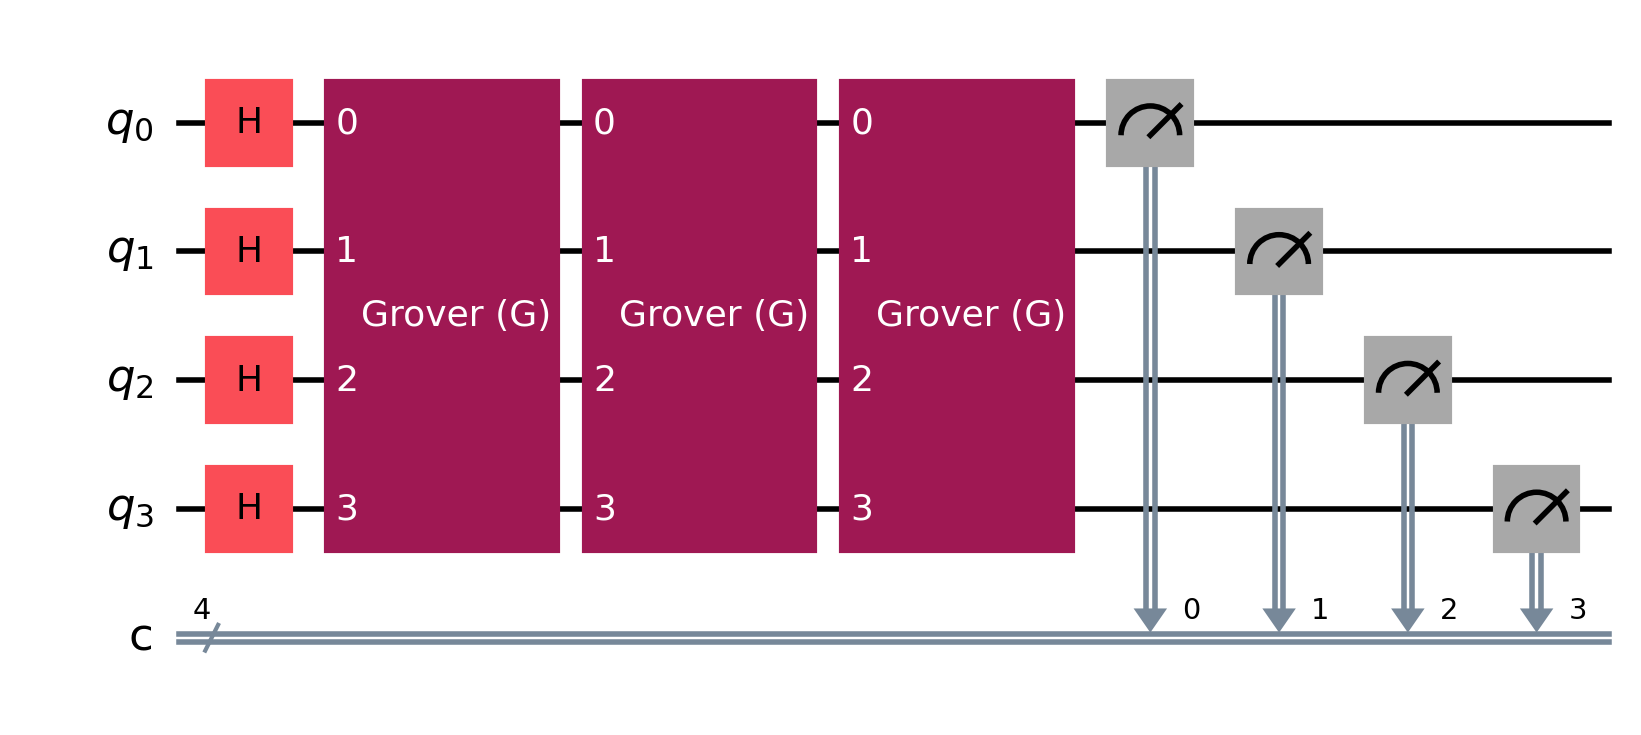

In [62]:
def create_grover_circuit_with_blocks(n, m=1):
    """
    Create a simplified Grover circuit visualization with blocks for Oracle (O) and Grover operator (G).

    Parameters:
    -----------
    n : int
        Number of qubits.
    m : int
        Number of marked states.
    """
    # Calculate the number of repetitions dynamically
    R = int(round((math.pi / 4) * math.sqrt((2**n) / m)))

    # Create the main circuit
    qc = QuantumCircuit(n, n)

    # Step 1: Apply H-gates for superposition
    qc.h(range(n))

    # Step 2: Create Oracle (O) as a subcircuit
    oracle = grover_oracle(n, m)
    oracle_gate = oracle.to_instruction(label="Oracle (O)")

    # Step 3: Create Diffuser as part of Grover operator (G)
    diffuser_circuit = diffuser(n)
    diffuser_gate = diffuser_circuit.to_instruction(label="Diffuser (D)")

    # Combine Oracle and Diffuser into Grover Operator (G)
    grover_op = QuantumCircuit(n, name='GroverOperator')
    grover_op.compose(oracle, range(n), inplace=True)
    grover_op.compose(diffuser_circuit, range(n), inplace=True)
    grover_gate = grover_op.to_instruction(label="Grover (G)")

    # Step 4: Apply Grover operator (G) dynamically based on R
    for _ in range(R):
        qc.append(grover_gate, range(n))

    # Step 5: Measurement
    qc.measure(range(n), range(n))

    return qc

qc = create_grover_circuit_with_blocks(n, m)
qc.draw('mpl', fold=-1, filename="block_circuit.eps")


True solutions: ['1111', '1110']
Number of Grover iterations = 2


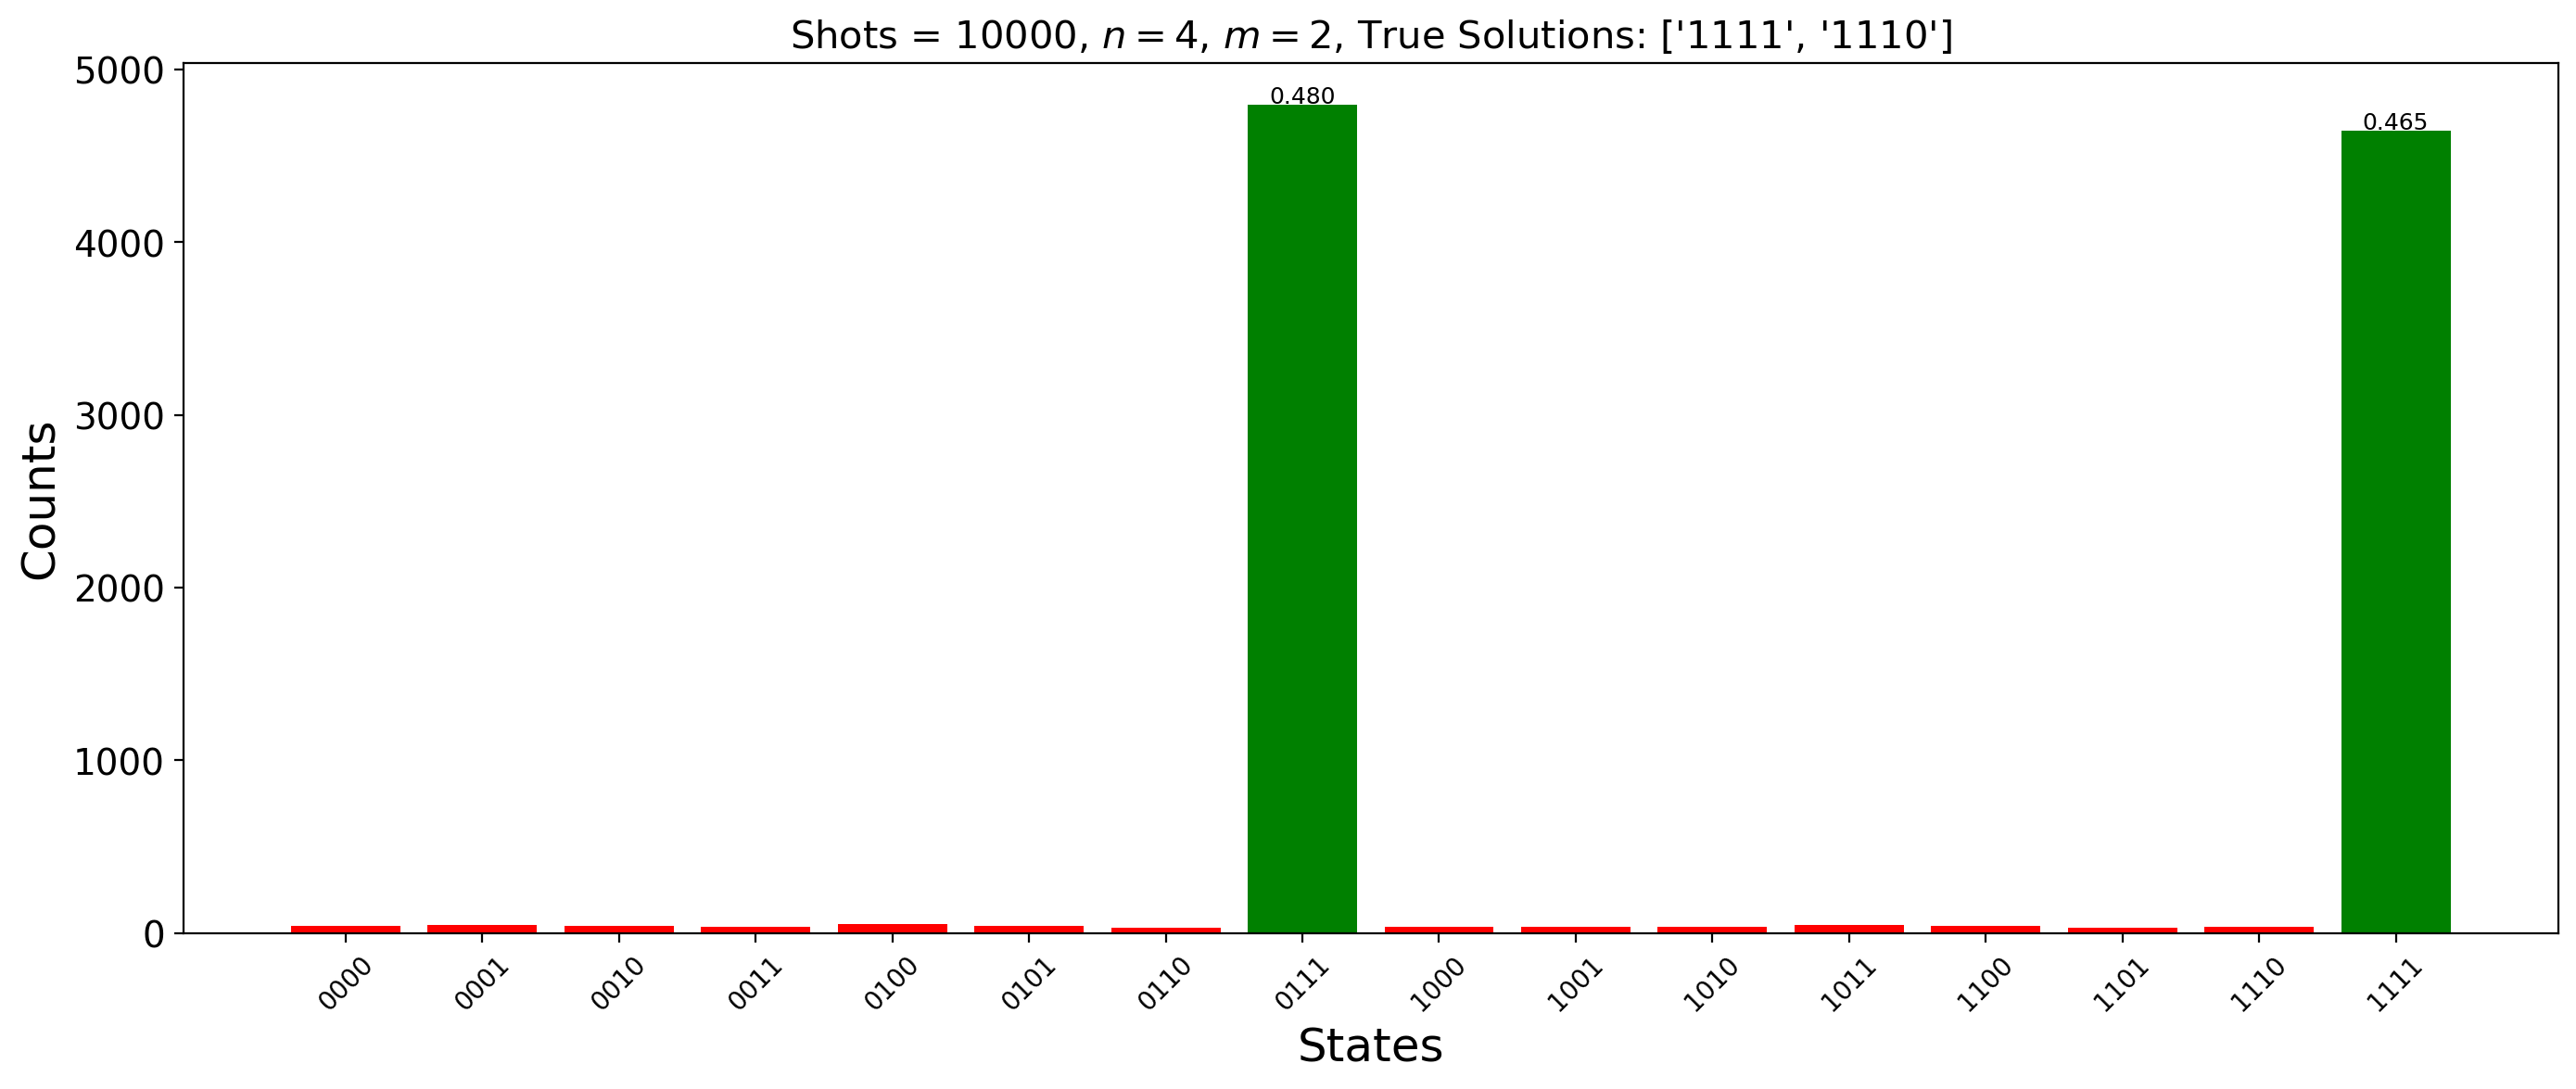

True solutions: ['111111', '111110']
Number of Grover iterations = 4


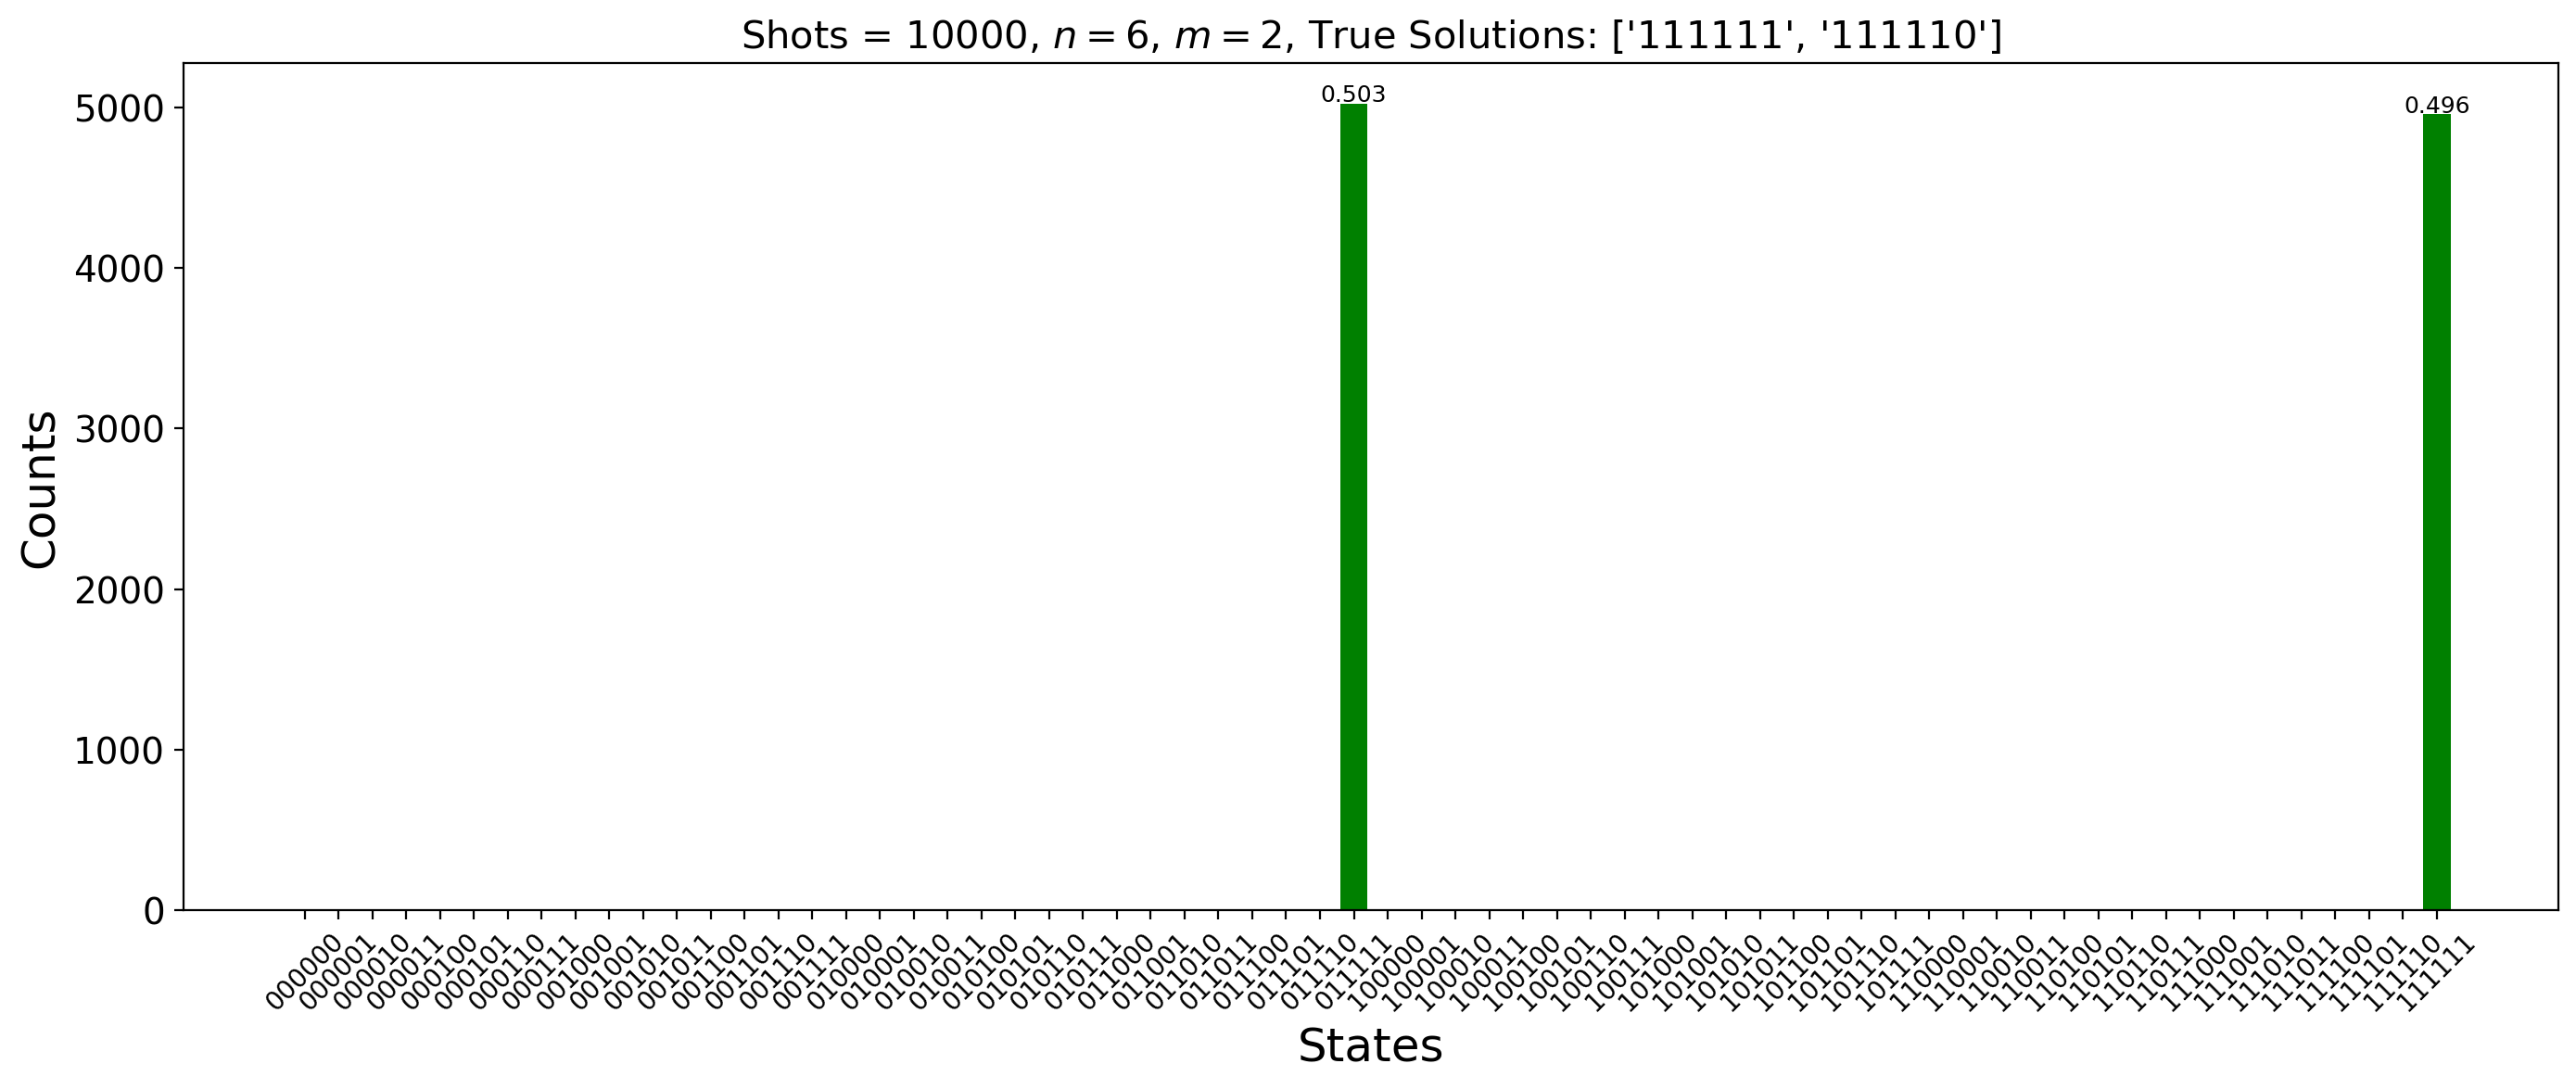

In [84]:
def plot_measurement_counts(measurement_counts, n, m, shots, true_solutions, name):
    """
    Plot bar chart of measurement counts for all 2^n states, accounting for Qiskit's little-endian ordering.
    Probabilities are displayed on top of bars for solution states. The plot width adjusts dynamically for large n.

    Parameters:
    -----------
    measurement_counts : dict
        Measured counts as a dictionary {state: count}.
    n : int
        Number of qubits.
    m : int
        Number of marked states.
    shots : int
        Total number of measurement shots.
    true_solutions : list
        List of marked states (binary strings) in **big-endian format** for comparison.
    """
    # Reverse the true_solutions to match Qiskit's little-endian measurement output
    true_solutions_reversed = [''.join(reversed(solution)) for solution in true_solutions]
    
    # Generate all possible states in the search space
    all_states = [bin(i)[2:].zfill(n) for i in range(2**n)]
    
    # Prepare counts and colors
    counts = []
    colors = []
    for state in all_states:
        # Get count for each state (default to 0 if not in results)
        count = measurement_counts.get(state, 0)
        counts.append(count)
        
        # Set colors: green for solutions, red for others
        if state in true_solutions_reversed:
            colors.append('green')
        else:
            colors.append('red')

    # Dynamically adjust figure width based on the number of states
    dynamic_width = max(14, 0.1 * (2 ** n))  # Base width 14, increases with n
    plt.figure(figsize=(dynamic_width, 6))

    # Create the bar plot
    bars = plt.bar(range(2**n), counts, color=colors)

    # Add probabilities on top of the solution bars only
    for i, state in enumerate(all_states):
        if state in true_solutions_reversed:
            probability = counts[i] / shots  # Compute probability
            plt.text(i, counts[i] + 10, f'{probability:.3f}', ha='center', fontsize=9)

    # Label axes and title
    plt.xticks(
        range(2**n), all_states, rotation=45, fontsize=8  # Rotate slightly to save space
    )
    plt.xlabel("States", fontsize=18 )
    plt.xticks(fontsize=10)
    plt.ylabel("Counts", fontsize=18)
    plt.yticks(fontsize=14)
    plt.title(f"Shots = {shots}, $n={n}$, $m={m}$, True Solutions: {true_solutions}", fontsize=15)
    plt.tight_layout()

    # Save the plot as EPS for vector graphics
    plt.savefig(f"{name}.eps", format='eps', dpi=1000)
    plt.show()

# searching for '111...1' (and '111...10' if m=2).
m = 2   # solutions to the search problem i.e. number of marked states
shots = 10000

for n in [4,6]:
    true_solutions = generate_true_solutions(n, m)
    print("True solutions:", true_solutions)

    _, measurement_counts = grover_search(n, m, shots)
    name =f"histogram_n={n}_m={m}"
    plot_measurement_counts(measurement_counts, n=n, m=m, shots=shots, true_solutions=true_solutions, name=name)    

# Multiple Shots for Statistical Confidence:
# ------------------------------------------
# Quantum measurements are inherently probabilistic. When a quantum circuit is executed,
# the state of the qubits collapses to one of the computational basis states according
# to the probability distribution determined by the amplitudes of the final quantum state.
#
# To ensure confidence in the result, the circuit is run multiple times (referred to as "shots").
# Each shot produces a single measurement outcome (a bitstring). By analyzing the distribution
# of the bitstrings obtained from all shots, we can identify the most frequently occurring
# outcome(s), which correspond to the solution(s) amplified by the algorithm (e.g., Grover's algorithm).
#
# This repetition helps mitigate the effect of quantum noise and randomness, ensuring that the
# observed solution is statistically significant and reliable.

In [71]:
print(measurement_counts)

{'110101': 1, '101101': 1, '111111': 4987, '110100': 1, '011111': 5010}


Number of Grover iterations = 2


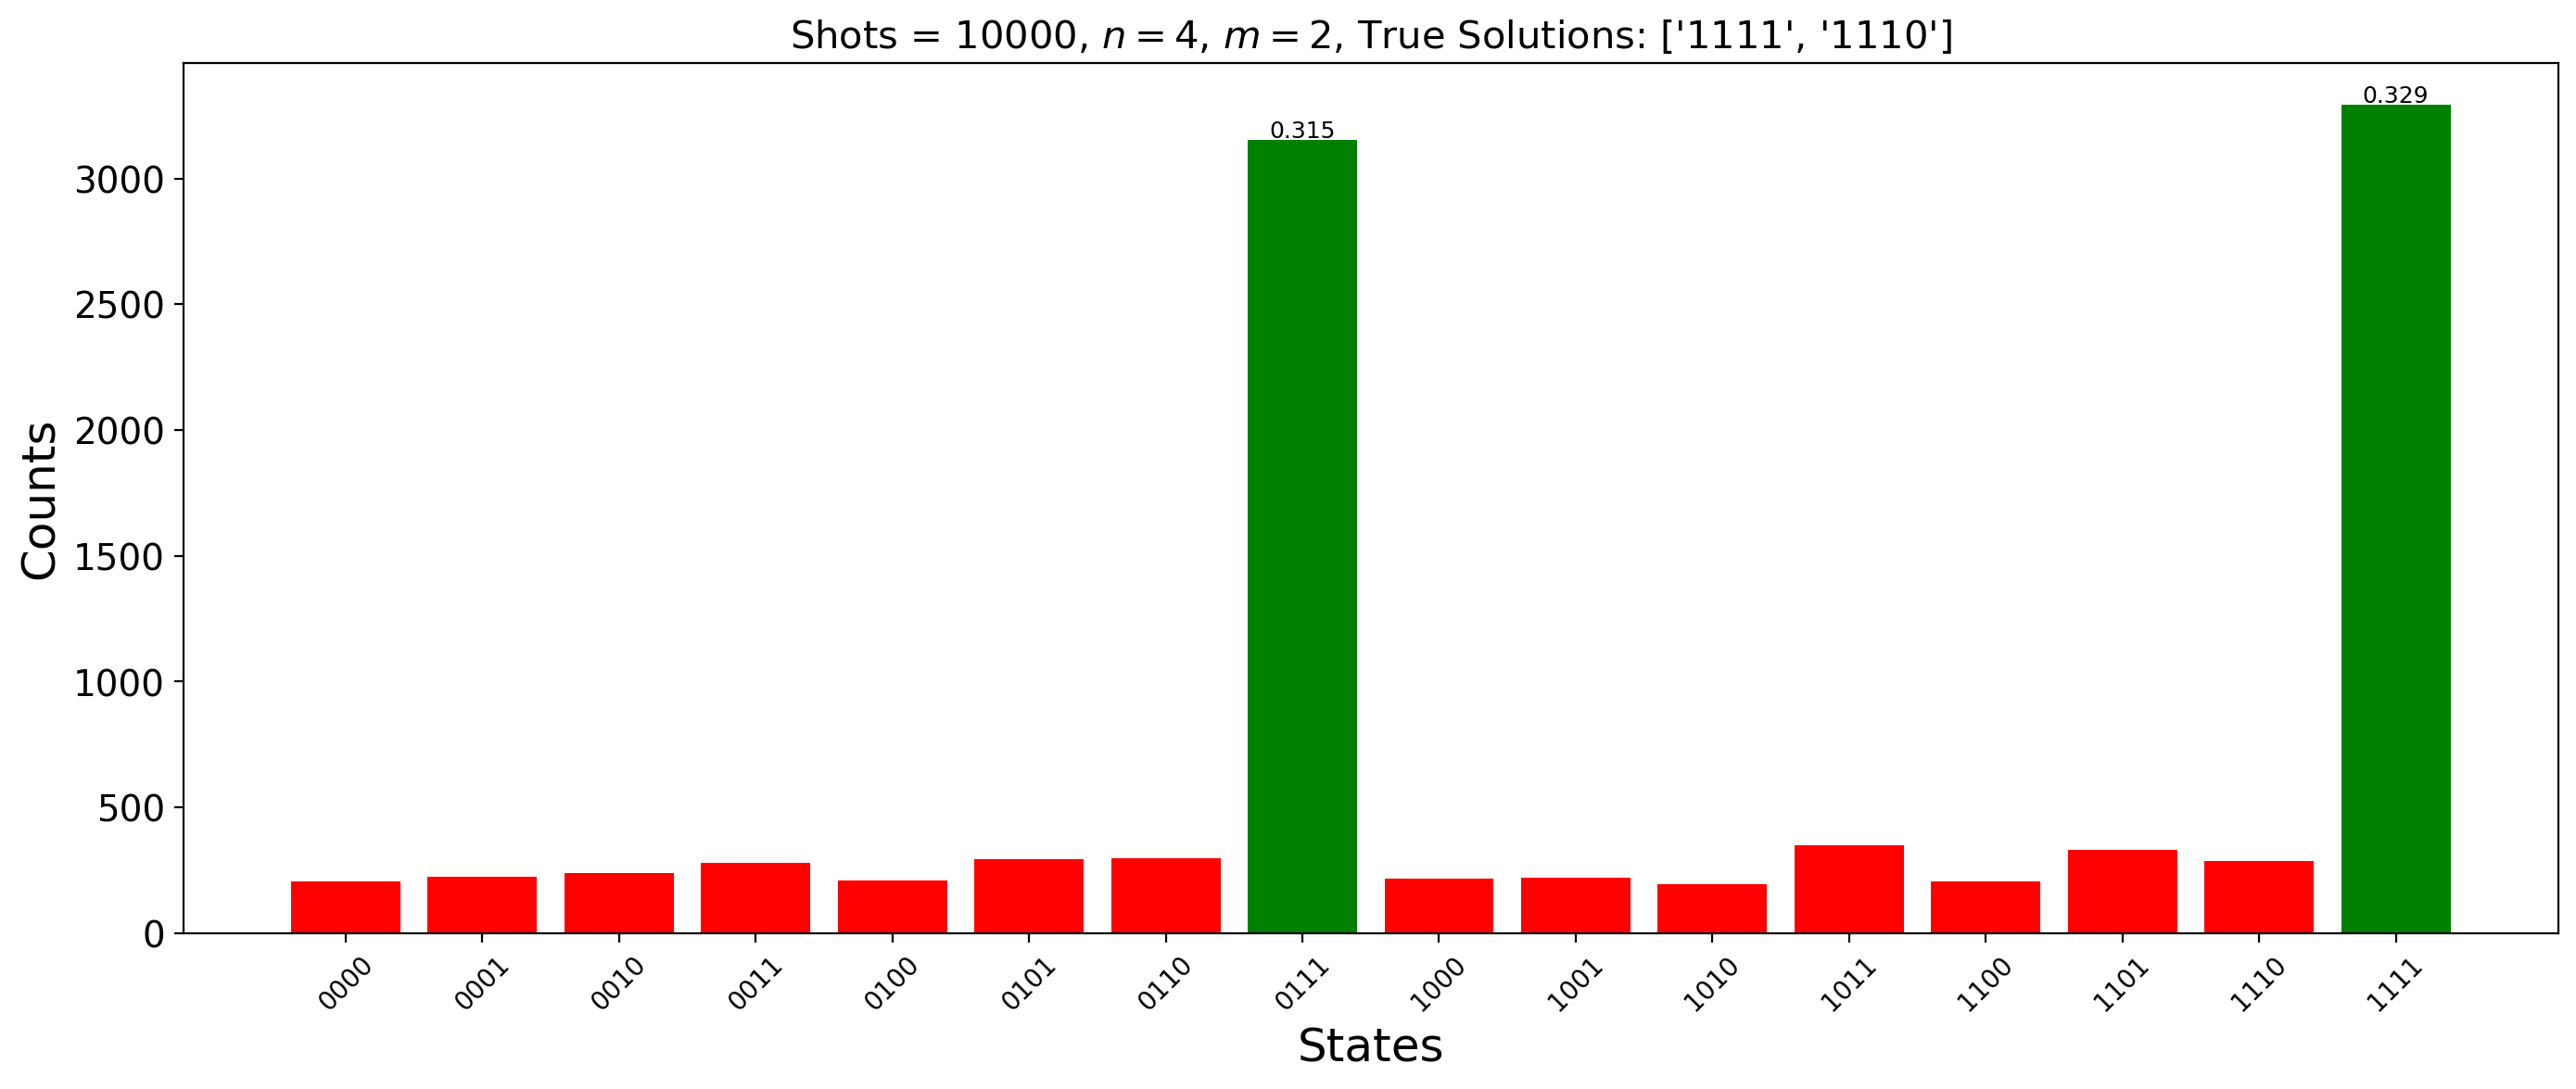

Number of Grover iterations = 4


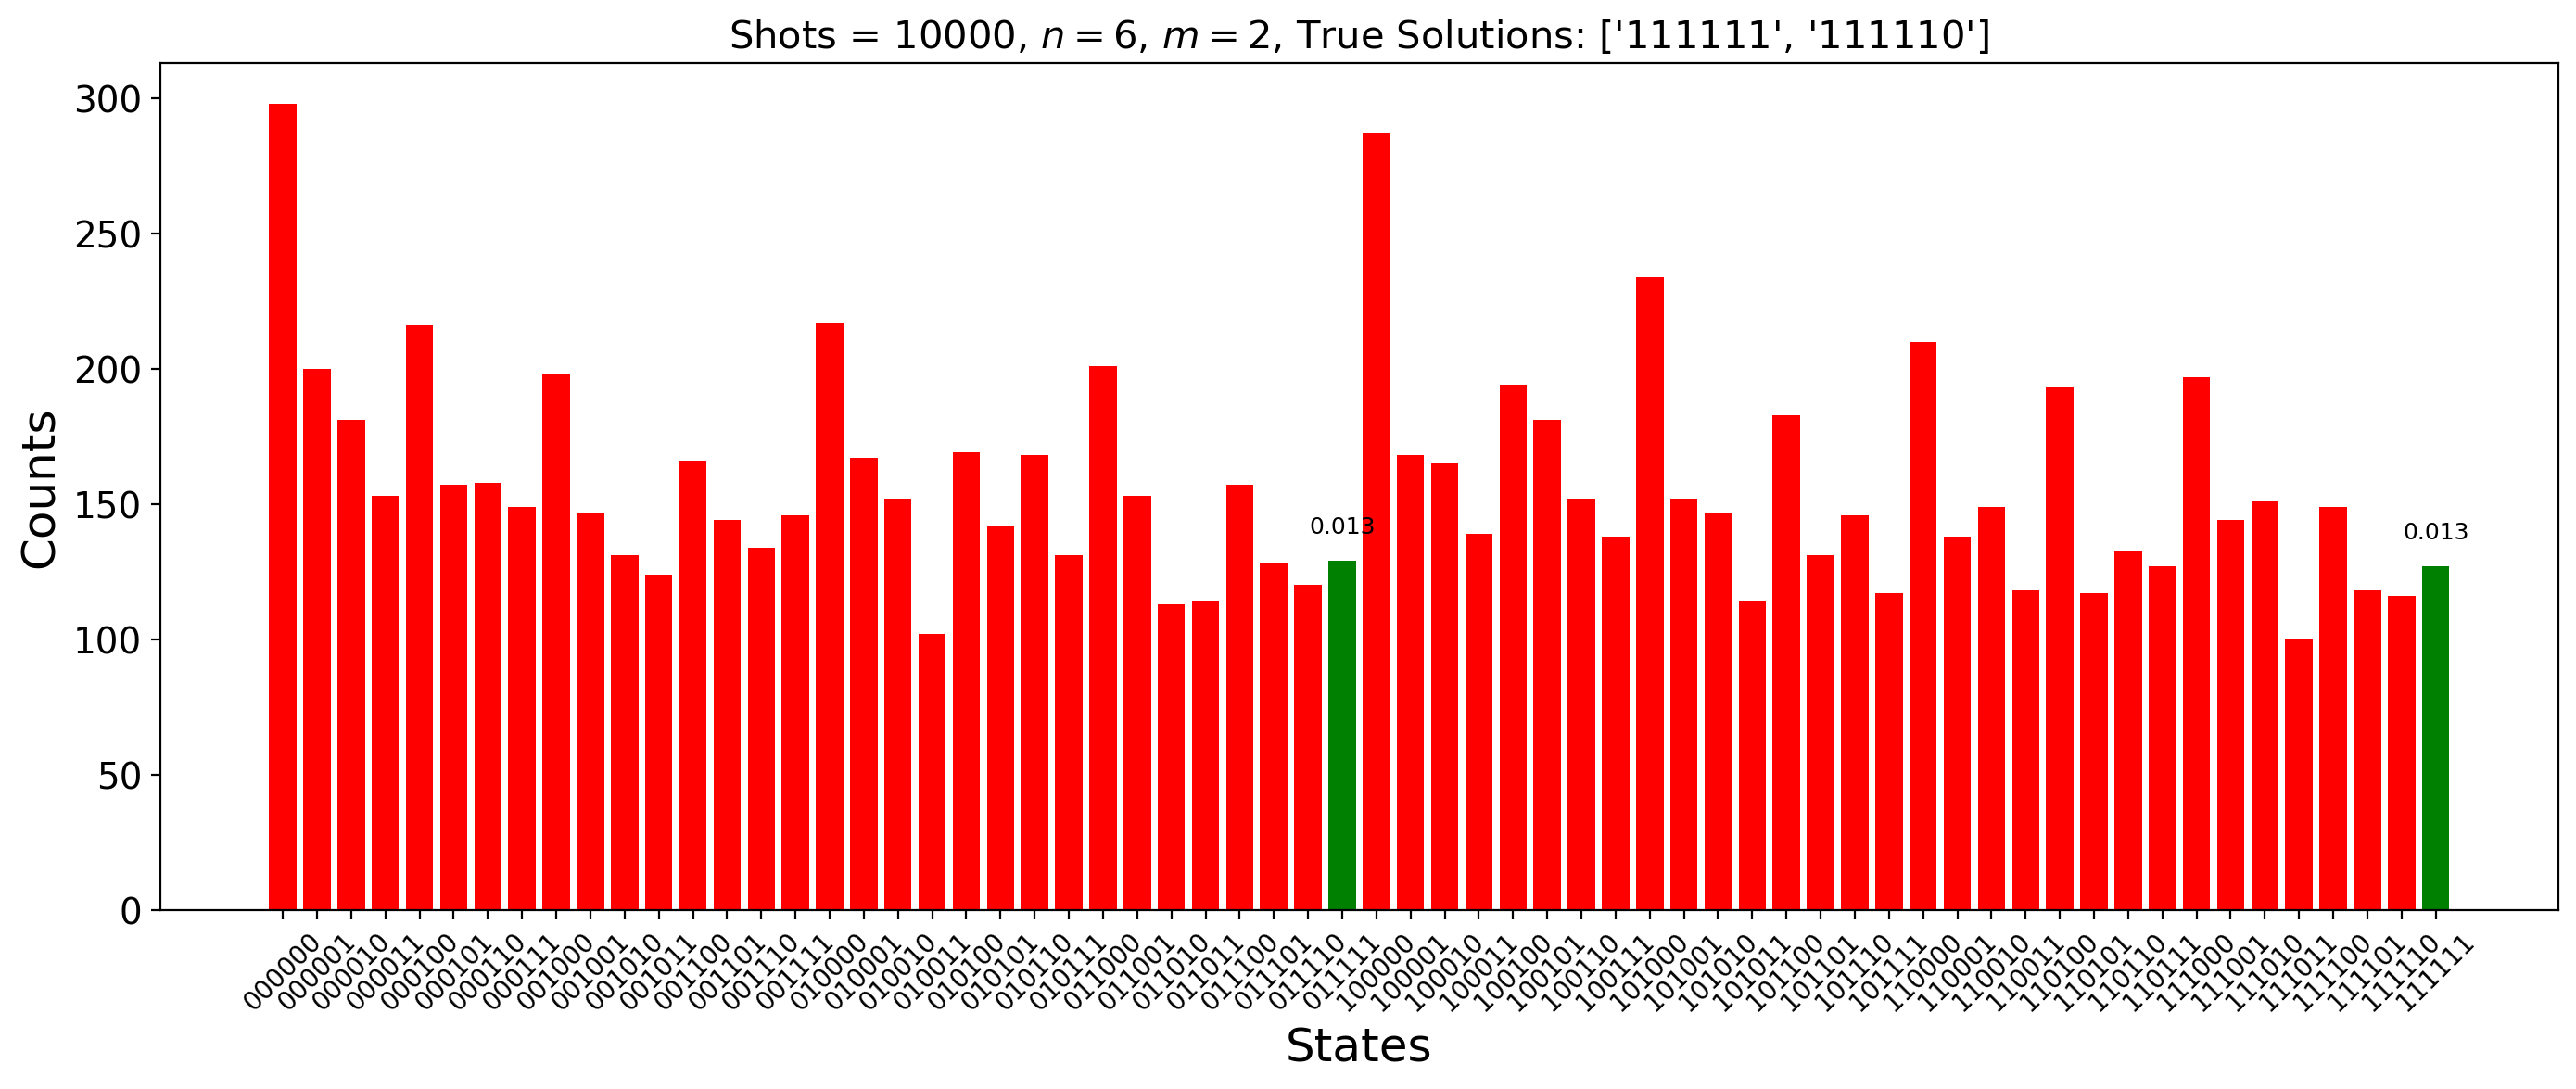

In [83]:
def run_grover_with_noise(qc, n, shots=2048):
    """
    Simulate Grover's algorithm under a noise model using GenericBackendV2.

    Parameters:
    -----------
    qc : QuantumCircuit
        Grover's algorithm circuit.
    n : int
        Number of qubits.
    shots : int
        Number of measurement shots.
    """
    # 1. Create a noise model from a generic backend
    fake_backend = GenericBackendV2(num_qubits=n)  # Fake backend with default noise properties
    noise_model = NoiseModel.from_backend(fake_backend)

    # 2. Use AerSimulator with the default noise model
    simulator = AerSimulator(noise_model=noise_model)

    # 3. Transpile the circuit for noisy simulation
    transpiled_qc = transpile(qc, simulator)

    # 4. Run the simulation
    result = simulator.run(transpiled_qc, shots=shots).result()
    counts = result.get_counts()
    return counts

m = 2  # Number of marked states
shots = 10000

for n in [4,6]:
    # Generate Grover's circuit
    final_circuit, _ = grover_search(n, m, shots)

    # Simulate with noise
    noisy_counts = run_grover_with_noise(final_circuit, n, shots)

    # Generate true solutions for title
    true_solutions = generate_true_solutions(n, m)

    name_noisy =f"histogram_noisy_n={n}_m={m}"

    # Plot results with noise effects
    plot_measurement_counts(noisy_counts, n=n, m=m, shots=shots, true_solutions=true_solutions, name=name_noisy )


In [96]:
fake_backend = GenericBackendV2(num_qubits=n)  # Fake backend with default noise properties
noise_model = NoiseModel.from_backend(fake_backend)
print(noise_model)

NoiseModel:
  Basis gates: ['cx', 'delay', 'id', 'measure', 'reset', 'rz', 'sx', 'x']
  Instructions with noise: ['id', 'measure', 'sx', 'x', 'cx']
  Qubits with noise: [0, 1, 2, 3, 4, 5]
  Specific qubit errors: [('cx', (0, 1)), ('cx', (1, 0)), ('cx', (0, 2)), ('cx', (2, 0)), ('cx', (0, 3)), ('cx', (3, 0)), ('cx', (0, 4)), ('cx', (4, 0)), ('cx', (0, 5)), ('cx', (5, 0)), ('cx', (1, 2)), ('cx', (2, 1)), ('cx', (1, 3)), ('cx', (3, 1)), ('cx', (1, 4)), ('cx', (4, 1)), ('cx', (1, 5)), ('cx', (5, 1)), ('cx', (2, 3)), ('cx', (3, 2)), ('cx', (2, 4)), ('cx', (4, 2)), ('cx', (2, 5)), ('cx', (5, 2)), ('cx', (3, 4)), ('cx', (4, 3)), ('cx', (3, 5)), ('cx', (5, 3)), ('cx', (4, 5)), ('cx', (5, 4)), ('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('id', (4,)), ('id', (5,)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('sx', (4,)), ('sx', (5,)), ('x', (0,)), ('x', (1,)), ('x', (2,)), ('x', (3,)), ('x', (4,)), ('x', (5,)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('m

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


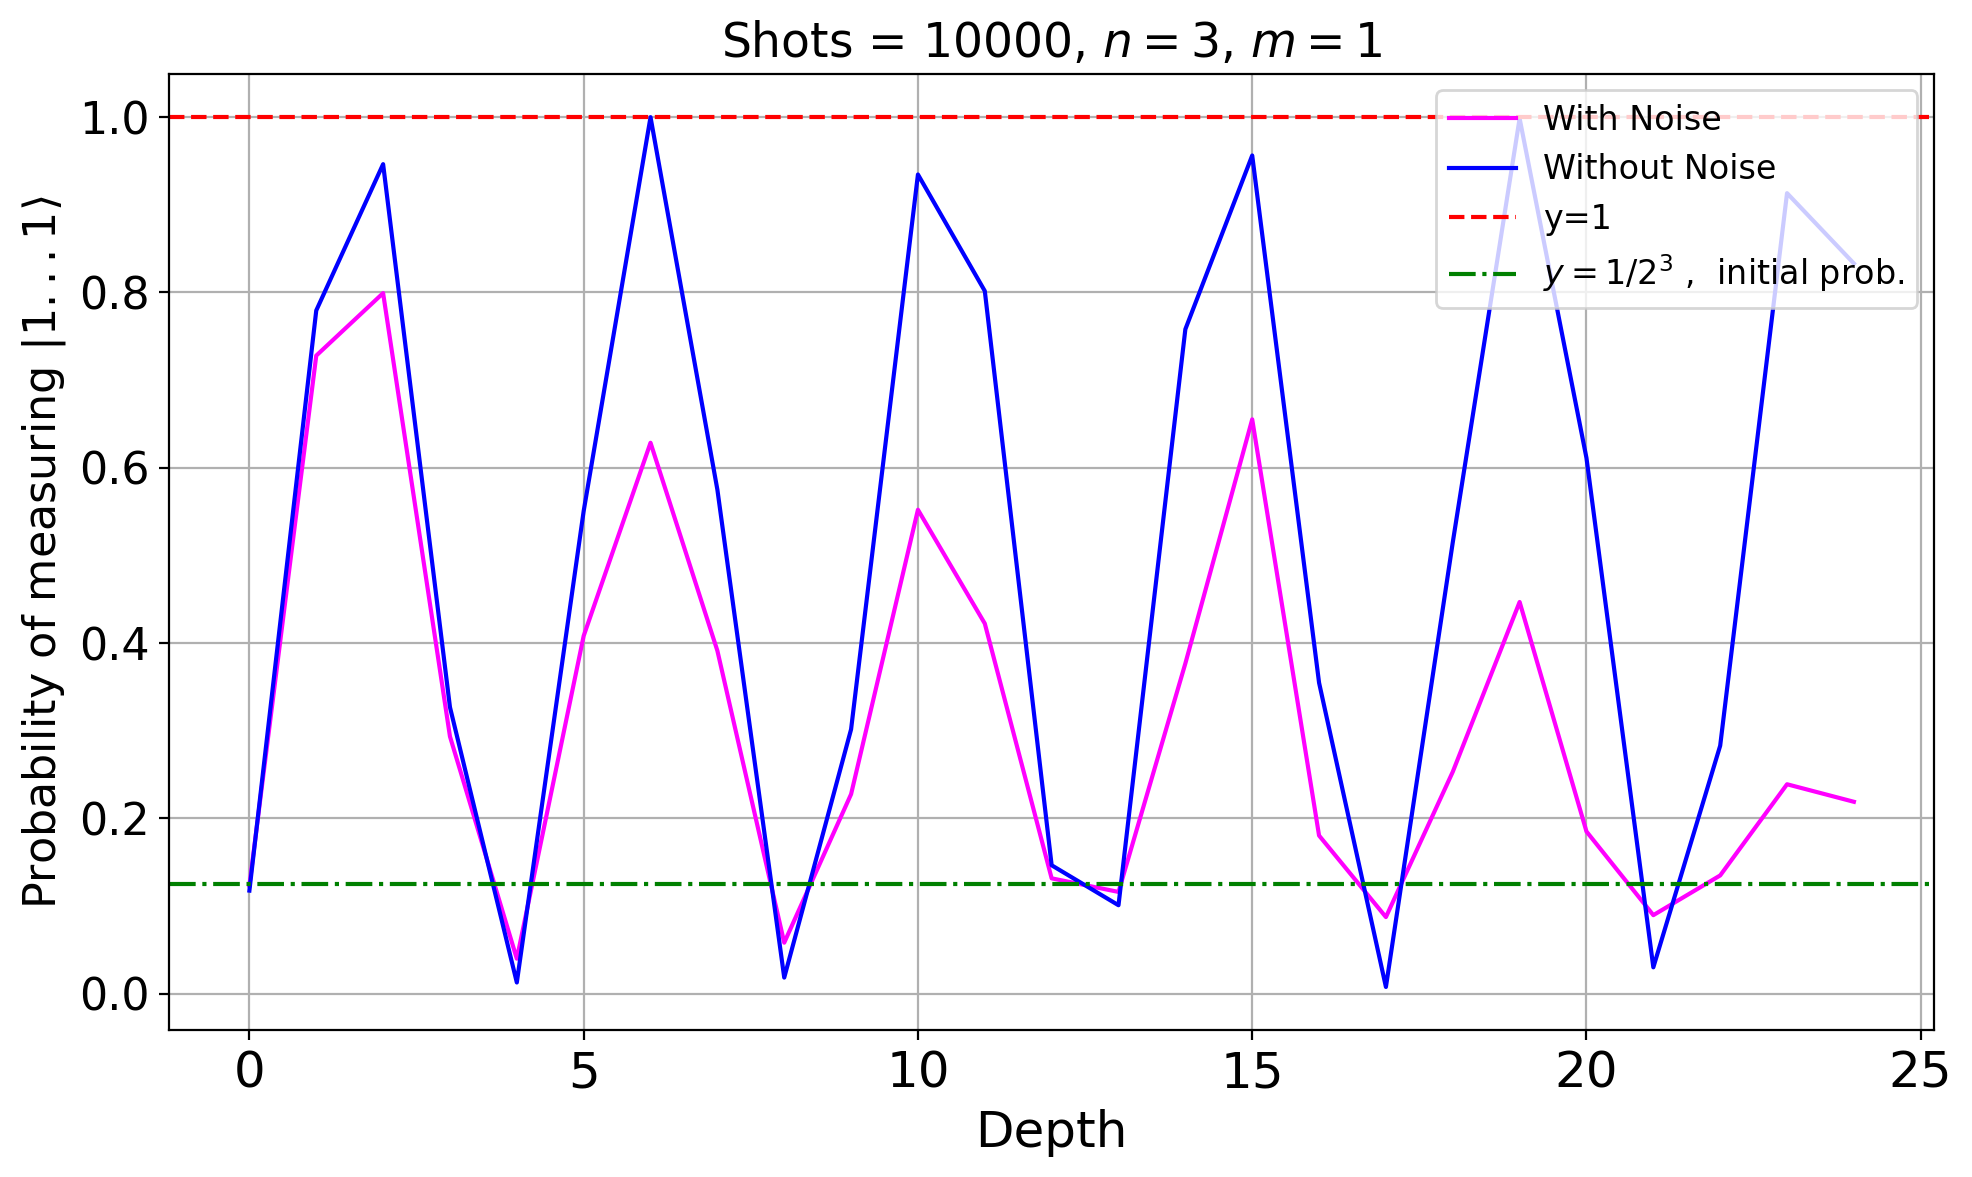

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


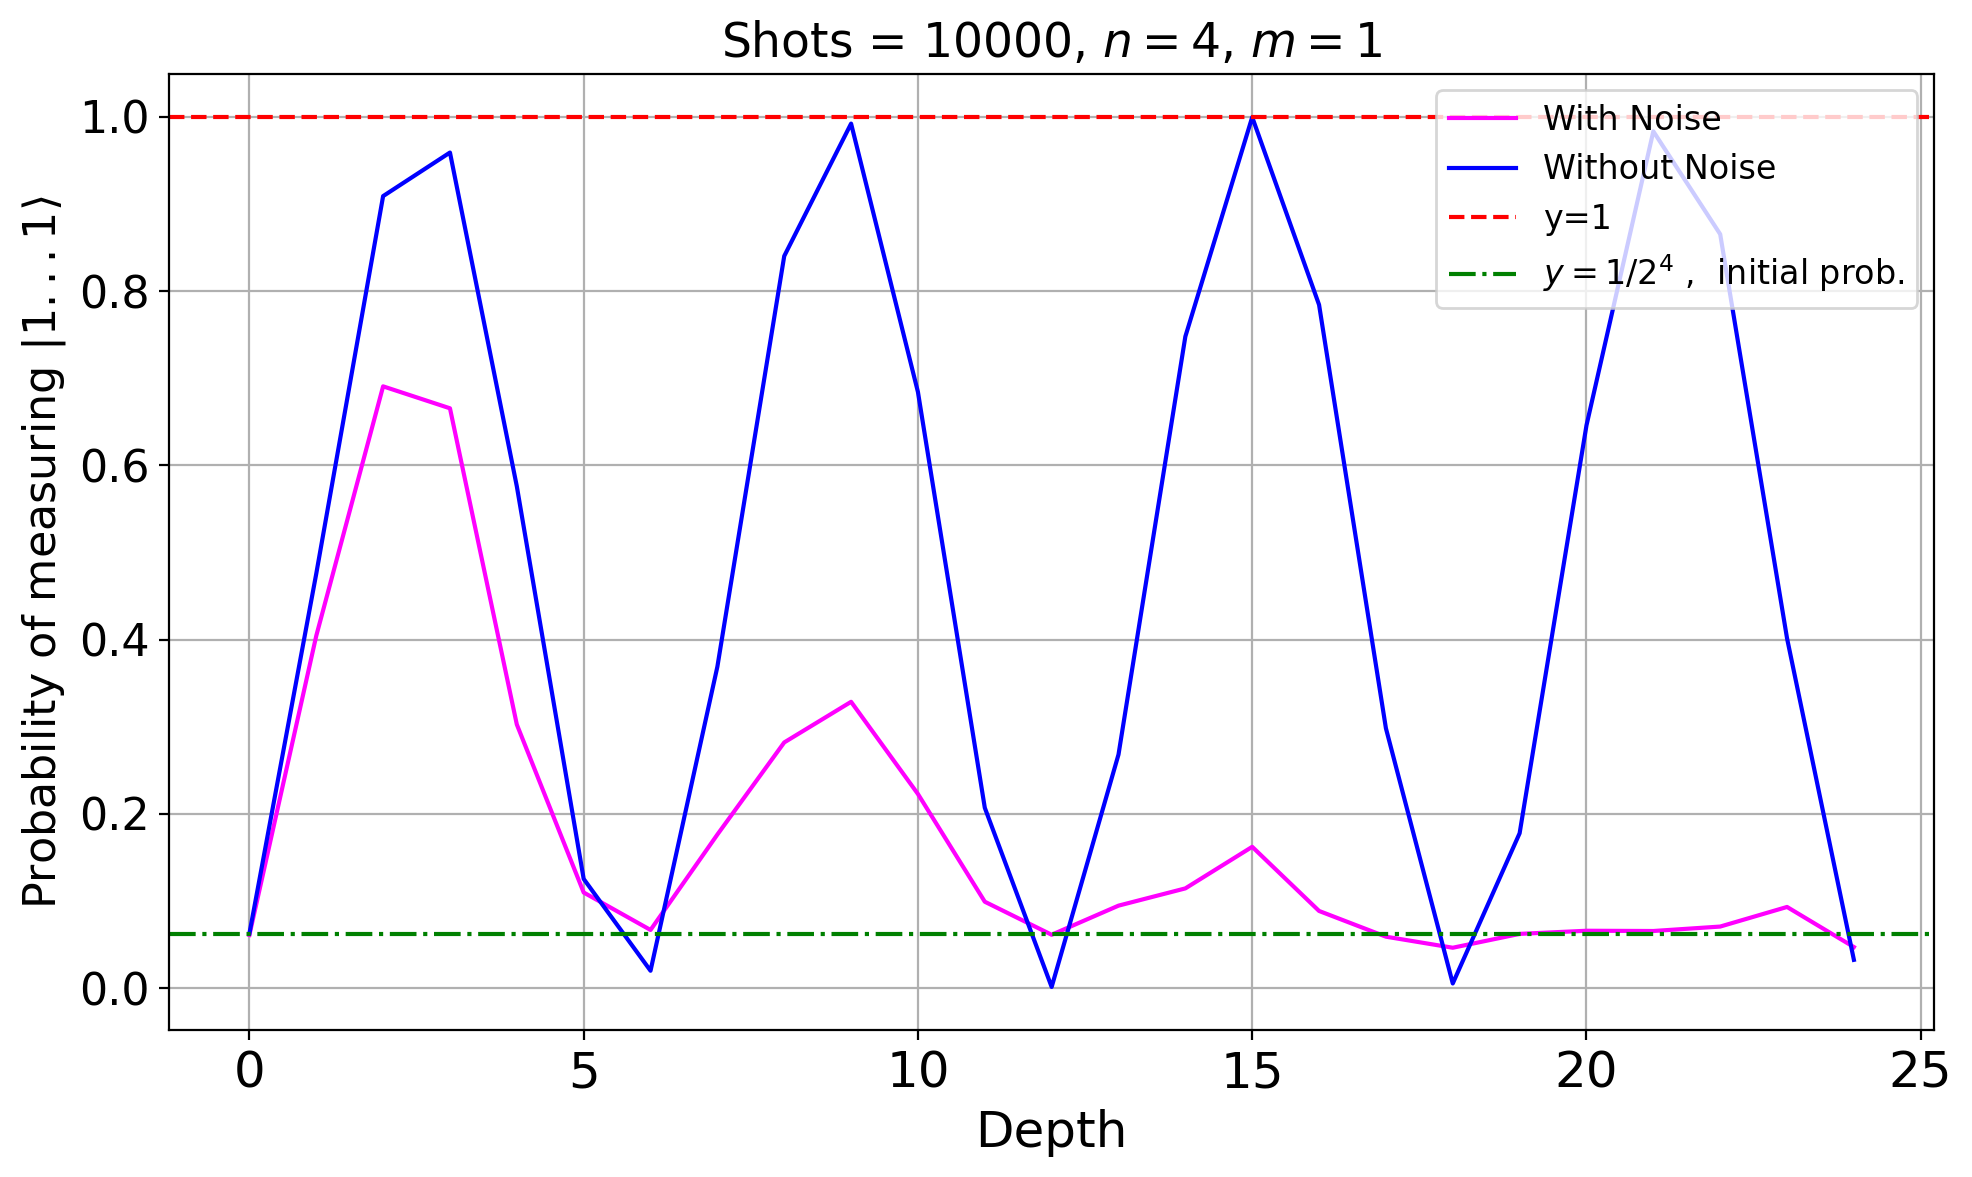

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


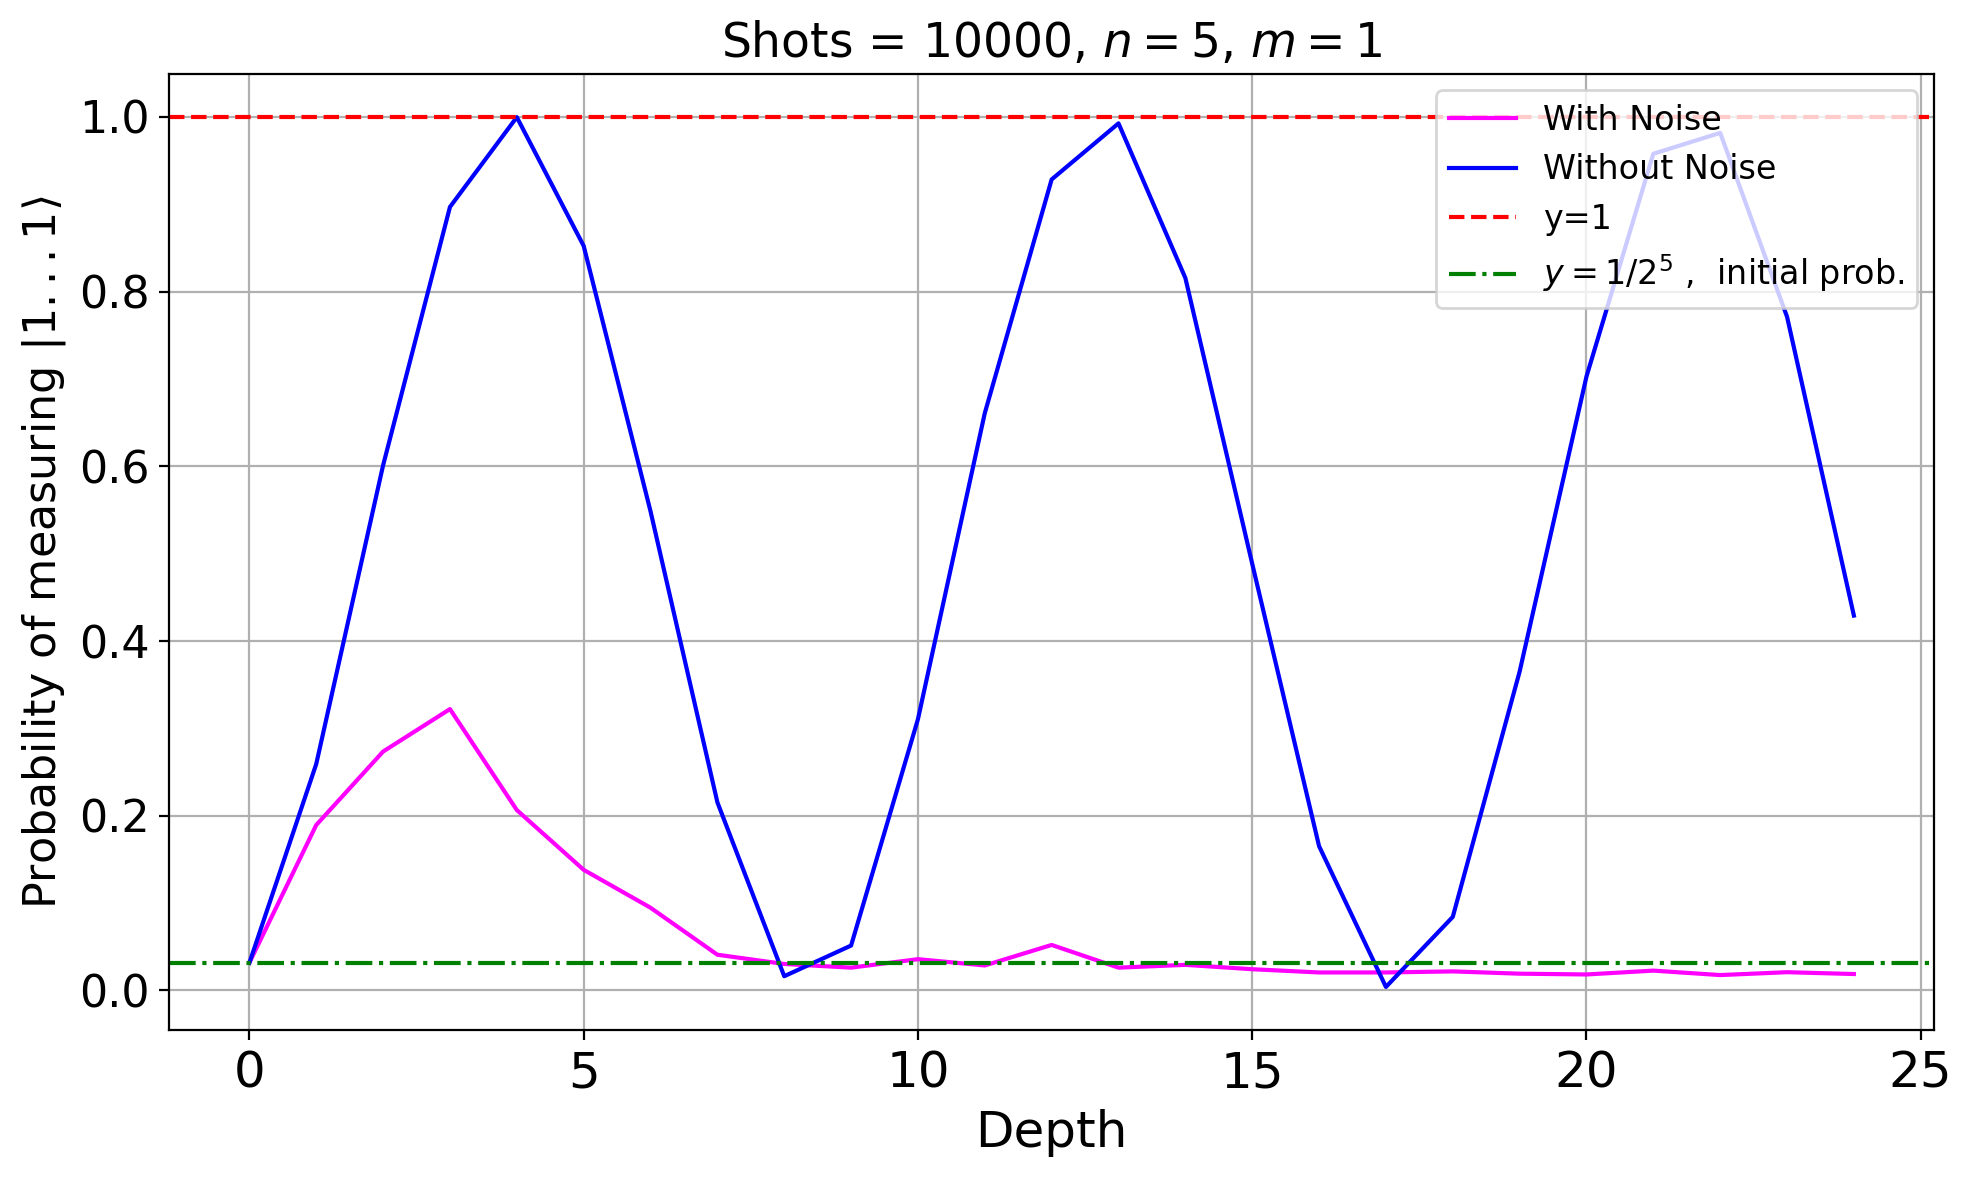

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


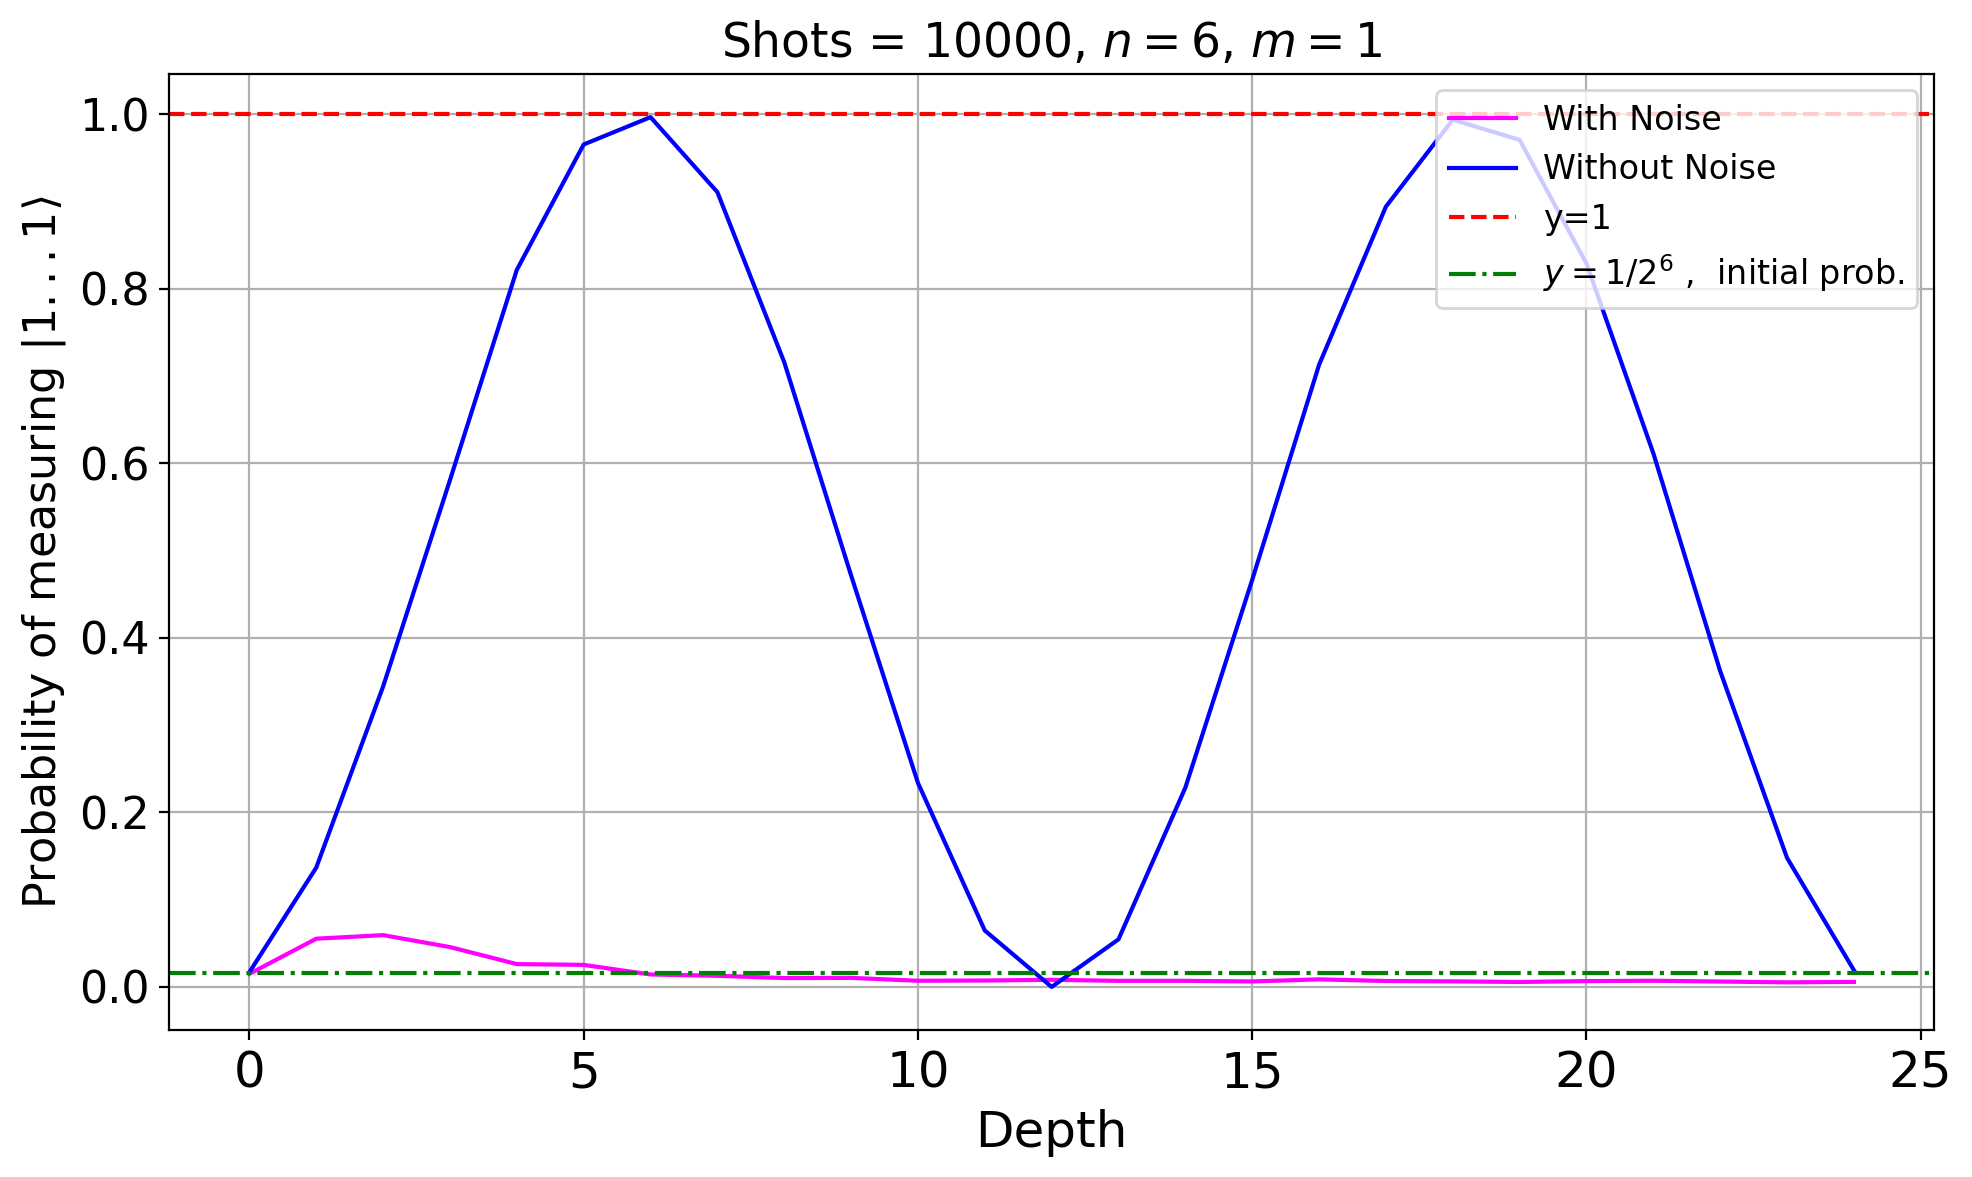

In [93]:
def run_grover_with_noise(qc, n, shots=2048):
    """
    Simulate Grover's algorithm under a noise model using GenericBackendV2.

    Parameters:
    -----------
    qc : QuantumCircuit
        Grover's algorithm circuit.
    n : int
        Number of qubits.
    shots : int
        Number of measurement shots.
    """
    # 1. Create a noise model from a generic backend
    fake_backend = GenericBackendV2(num_qubits=n)  # Fake backend with default noise properties
    noise_model = NoiseModel.from_backend(fake_backend)

    # 2. Use AerSimulator with the default noise model
    simulator = AerSimulator(noise_model=noise_model)

    # 3. Transpile the circuit for noisy simulation
    transpiled_qc = transpile(qc, simulator)

    # 4. Run the simulation
    result = simulator.run(transpiled_qc, shots=shots).result()
    counts = result.get_counts()
    return counts

def run_grover_without_noise(qc, shots=2048):
    """
    Simulate Grover's algorithm without noise.

    Parameters:
    -----------
    qc : QuantumCircuit
        Grover's algorithm circuit.
    shots : int
        Number of measurement shots.
    """
    simulator = AerSimulator()
    transpiled_qc = transpile(qc, simulator)
    result = simulator.run(transpiled_qc, shots=shots).result()
    counts = result.get_counts()
    return counts

def plot_sinusoidal_amplitude(n, m=1, shots=2048):
    """
    Plot the relative appearance of the target state as a function of depth in Grover's algorithm.

    Parameters:
    -----------
    n : int
        Number of qubits.
    m : int
        Number of marked states.
    shots : int
        Number of measurement shots.
    """
    # Initialize parameters
    repetitions = range(25)
    results_target_noise = []
    results_target_no_noise = []
    target_state = '1' * n

    # Simulate Grover's algorithm for multiple repetitions
    for repetit in repetitions:
        # Create circuit for each repetition
        qc = QuantumCircuit(n, n)
        for qubit in range(n):
            qc.h(qubit)

        # Apply Grover operator repetit times
        G = grover_operator(n, m)
        for _ in range(repetit):
            qc.compose(G, range(n), inplace=True)

        # Measure all qubits
        qc.measure(range(n), range(n))

        # Run the simulation with noise
        counts_noise = run_grover_with_noise(qc, n, shots)
        occurrences_noise = counts_noise.get(target_state, 0)
        results_target_noise.append(occurrences_noise / shots)

        # Run the simulation without noise
        counts_no_noise = run_grover_without_noise(qc, shots)
        occurrences_no_noise = counts_no_noise.get(target_state, 0)
        results_target_no_noise.append(occurrences_no_noise / shots)

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(repetitions, results_target_noise, label="With Noise", color='magenta')
    plt.plot(repetitions, results_target_no_noise, label="Without Noise", color='blue')
    plt.axhline(1.0, color='r', linestyle='--', label="y=1")

    # Add horizontal line for random probability m/2^n
    random_prob = m / (2**n)
    plt.axhline(random_prob, color='green', linestyle='-.', label=fr"$y={m}/2^{n}$ ,  initial prob.")

    plt.xlabel(r"Depth", fontsize=18)
    plt.xticks(fontsize=18)
    plt.ylabel(r"Probability of measuring $|1...1\rangle $", fontsize=16)
    plt.yticks(fontsize=16)
    plt.title(f"Shots = {shots}, $n={n}$, $m={m}$", fontsize=17)
    plt.legend(fontsize=12, loc=1)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"sinus_n={n}.eps", format='eps', dpi=1000)
    plt.show()

# Example usage for multiple n and m
ns = [3,4,5,6]
m = 1
shots = 10000
for n in ns:
    plot_sinusoidal_amplitude(n, m, shots)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


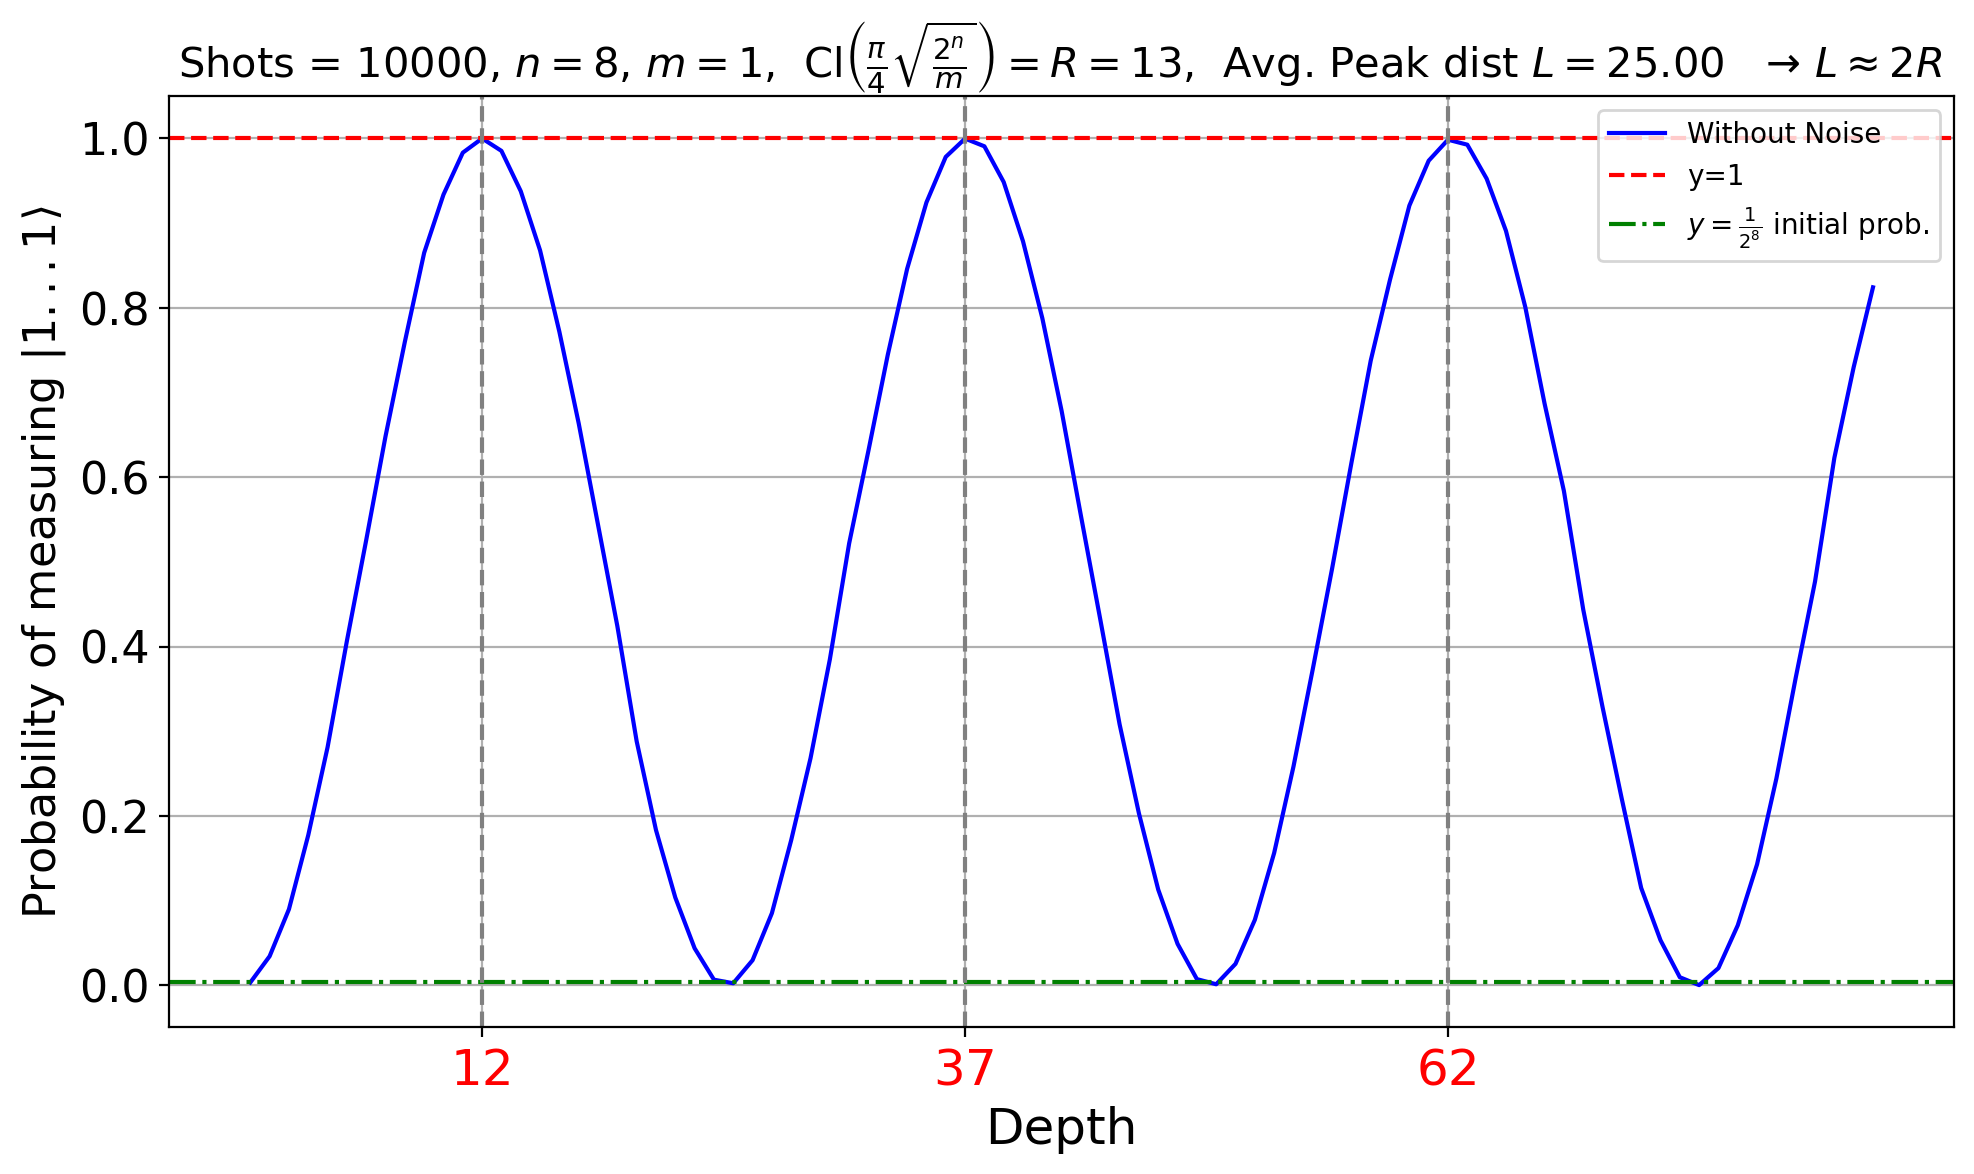

In [88]:
def plot_sinusoidal_with_peaks(n, m=1, shots=2048):
    """
    Plot the probability of measuring the target state as a function of Grover's depth.
    Highlight peaks with vertical lines and verify the period matches theoretical R.

    Parameters:
    -----------
    n : int
        Number of qubits.
    m : int
        Number of marked states.
    shots : int
        Number of measurement shots.
    """
    # Initialize parameters
    repetitions = range(85)
    results_target = []
    target_state = '1' * n

    # Simulate Grover's algorithm for multiple repetitions
    for repetit in repetitions:
        # Create circuit for each repetition
        qc = QuantumCircuit(n, n)
        for qubit in range(n):
            qc.h(qubit)

        # Apply Grover operator repetit times
        G = grover_operator(n, m)
        for _ in range(repetit):
            qc.compose(G, range(n), inplace=True)

        # Measure all qubits
        qc.measure(range(n), range(n)) # measures all n qubits in the quantum circuit and maps their measurement results to n classical bits in the classical register.

        # Simulate without noise
        simulator = AerSimulator() # Simulate the quantum circuit on a classical computer
        transpiled_qc = transpile(qc, simulator)
        result = simulator.run(transpiled_qc, shots=shots).result() # object containing the simulation outcomes.
        counts = result.get_counts() # Retrieves the measurement results as a dictionary where: Keys =  Bitstrings , Values = # of times each bitstring was observed across all shots.

        occurrences = counts.get(target_state, 0)
        results_target.append(occurrences / shots)

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(repetitions, results_target, label="Without Noise", color='blue')
    plt.axhline(1.0, color='r', linestyle='--', label="y=1")

    # Add horizontal line for random probability m/2^n
    random_prob = m / (2**n)
    plt.axhline(random_prob, color='green', linestyle='-.', label=fr"$y=\frac{{{m}}}{{2^{n}}}$ initial prob.")

    # Draw vertical lines at peaks and highlight x values
    peaks = [i for i in range(1, len(results_target)-1) if results_target[i-1] < results_target[i] > results_target[i+1]]
    for peak in peaks:
        plt.axvline(peak, color='gray', linestyle='--')

    # Display only peak positions on the x-axis
    plt.xticks(peaks, [str(peak) for peak in peaks], fontsize=12)

    # Highlight peak labels in red
    for label in plt.gca().get_xticklabels():
        label.set_color('red')

    # Compute average distance between peaks
    if len(peaks) > 1:
        distances = [peaks[i+1] - peaks[i] for i in range(len(peaks)-1)]
        avg_distance = sum(distances) / len(distances)
    else:
        avg_distance = None

    # Verify theoretical R
    R = round(math.pi / 4 * math.sqrt(2**n / m))
    formula =r"\mathrm{Cl}\left(\frac{\pi}{4} \sqrt{\frac{2^n}{m}} \right)"
    plt.title(fr"Shots = {shots}, $n={n}$, $m={m}$,  ${formula}= R = {R}$,  Avg. Peak dist $L = {avg_distance:.2f} \quad \to  \ L \approx 2R$ ", fontsize=15)
    plt.xlabel("Depth", fontsize=18)
    plt.xticks(fontsize=18)
    plt.ylabel(r"Probability of measuring $|1...1\rangle $", fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"sinus_peaks_n={n}.eps", format='eps', dpi=1000)
    plt.show()


# Example usage
n = 8
m = 1
shots = 10000
plot_sinusoidal_with_peaks(n, m, shots)